# 🧠 Нечеткая логика: Задача о чаевых

## 📖 Постановка задачи

Представьте, что вы в ресторане и хотите определить размер чаевых в зависимости от двух факторов:

1. **Качество еды** (от 0 до 10)
   - Прогорклая (0-3)
   - Нормальная (4-7)  
   - Очень вкусная (8-10)

2. **Качество обслуживания** (от 0 до 10)
   - Плохое (0-3)
   - Удовлетворительное (4-7)
   - Отличное (8-10)

**Размер чаевых**:
- Минимум: 5%
- Стандарт: 15%  
- Хорошие: 20%

## 🎯 Цель: Построить нечеткую систему, которая будет определять размер чаевых на основе этих двух входных параметров

# 1 Импорт библиотек и настройка

In [2]:
# ЯЧЕЙКА 1: Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import pandas as pd
from IPython.display import display, HTML, Markdown
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

print("✅ Библиотеки успешно загружены!")

✅ Библиотеки успешно загружены!


# 2: Функция для форматированного вывода

In [3]:
# ЯЧЕЙКА 2: Вспомогательная функция для вывода Markdown
def md(text):
    """Функция для вывода форматированного текста"""
    display(Markdown(text))

print("✅ Вспомогательная функция создана!")

✅ Вспомогательная функция создана!


# 3: Введение и постановка задачи

In [4]:
# ЯЧЕЙКА 3: Введение в задачу
md("""
# 🧠 Нечеткая логика: Задача о чаевых

## 📖 Постановка задачи

Представьте, что вы в ресторане и хотите определить размер чаевых в зависимости от двух факторов:

1. **Качество еды** (от 0 до 10)
   - Прогорклая (0-3)
   - Нормальная (4-7)  
   - Очень вкусная (8-10)

2. **Качество обслуживания** (от 0 до 10)
   - Плохое (0-3)
   - Удовлетворительное (4-7)
   - Отличное (8-10)

**Размер чаевых**:
- Минимум: 5%
- Стандарт: 15%  
- Хорошие: 20%

## 🎯 Цель: Построить нечеткую систему, которая будет определять размер чаевых на основе этих двух входных параметров
""")


# 🧠 Нечеткая логика: Задача о чаевых

## 📖 Постановка задачи

Представьте, что вы в ресторане и хотите определить размер чаевых в зависимости от двух факторов:

1. **Качество еды** (от 0 до 10)
   - Прогорклая (0-3)
   - Нормальная (4-7)  
   - Очень вкусная (8-10)

2. **Качество обслуживания** (от 0 до 10)
   - Плохое (0-3)
   - Удовлетворительное (4-7)
   - Отличное (8-10)

**Размер чаевых**:
- Минимум: 5%
- Стандарт: 15%  
- Хорошие: 20%

## 🎯 Цель: Построить нечеткую систему, которая будет определять размер чаевых на основе этих двух входных параметров


# 4: Создание лингвистических переменных

# 4: Создание лингвистических переменных

In [5]:
# ЯЧЕЙКА 4: Создание переменных нечеткой логики

# Входная переменная: качество еды (от 0 до 10)
food = ctrl.Antecedent(np.arange(0, 11, 0.1), 'food_quality')

# Входная переменная: качество обслуживания (от 0 до 10)
service = ctrl.Antecedent(np.arange(0, 11, 0.1), 'service_quality')

# Выходная переменная: размер чаевых (от 0 до 25 процентов)
tip = ctrl.Consequent(np.arange(0, 26, 0.1), 'tip_percentage')

print("✅ Переменные созданы:")
print(f"   - food_quality: от 0 до 10")
print(f"   - service_quality: от 0 до 10")
print(f"   - tip_percentage: от 0 до 25%")

✅ Переменные созданы:
   - food_quality: от 0 до 10
   - service_quality: от 0 до 10
   - tip_percentage: от 0 до 25%


# 5: Определение функций принадлежности для еды

In [6]:
# ЯЧЕЙКА 5: Функции принадлежности для качества еды

# Прогорклая еда (0-5)
food['прогорклая'] = fuzz.trimf(food.universe, [0, 0, 5])

# Нормальная еда (3-8)
food['нормальная'] = fuzz.trimf(food.universe, [3, 5, 8])

# Вкусная еда (6-10)
food['вкусная'] = fuzz.trimf(food.universe, [6, 10, 10])

print("✅ Функции принадлежности для 'Еда':")
print("   - прогорклая: треугольная (0, 0, 5)")
print("   - нормальная: треугольная (3, 5, 8)")
print("   - вкусная: треугольная (6, 10, 10)")

✅ Функции принадлежности для 'Еда':
   - прогорклая: треугольная (0, 0, 5)
   - нормальная: треугольная (3, 5, 8)
   - вкусная: треугольная (6, 10, 10)


# 6: Определение функций принадлежности для обслуживания

In [7]:
# ЯЧЕЙКА 6: Функции принадлежности для качества обслуживания

# Плохое обслуживание (0-5)
service['плохое'] = fuzz.trimf(service.universe, [0, 0, 5])

# Нормальное обслуживание (3-8)
service['нормальное'] = fuzz.trimf(service.universe, [3, 5, 8])

# Отличное обслуживание (6-10)
service['отличное'] = fuzz.trimf(service.universe, [6, 10, 10])

print("✅ Функции принадлежности для 'Обслуживание':")
print("   - плохое: треугольная (0, 0, 5)")
print("   - нормальное: треугольная (3, 5, 8)")
print("   - отличное: треугольная (6, 10, 10)")

✅ Функции принадлежности для 'Обслуживание':
   - плохое: треугольная (0, 0, 5)
   - нормальное: треугольная (3, 5, 8)
   - отличное: треугольная (6, 10, 10)


# 7: Определение функций принадлежности для чаевых

In [8]:
# ЯЧЕЙКА 7: Функции принадлежности для размера чаевых

# Минимум чаевых (5%)
tip['минимум'] = fuzz.trimf(tip.universe, [0, 5, 10])

# Стандартные чаевые (15%)
tip['стандарт'] = fuzz.trimf(tip.universe, [8, 15, 20])

# Хорошие чаевые (20%)
tip['хорошие'] = fuzz.trimf(tip.universe, [15, 20, 25])

print("✅ Функции принадлежности для 'Чаевые':")
print("   - минимум: 5% (треугольная 0,5,10)")
print("   - стандарт: 15% (треугольная 8,15,20)")
print("   - хорошие: 20% (треугольная 15,20,25)")

✅ Функции принадлежности для 'Чаевые':
   - минимум: 5% (треугольная 0,5,10)
   - стандарт: 15% (треугольная 8,15,20)
   - хорошие: 20% (треугольная 15,20,25)


# 8: Визуализация функций принадлежности (Часть 1)

<Figure size 1000x500 with 0 Axes>

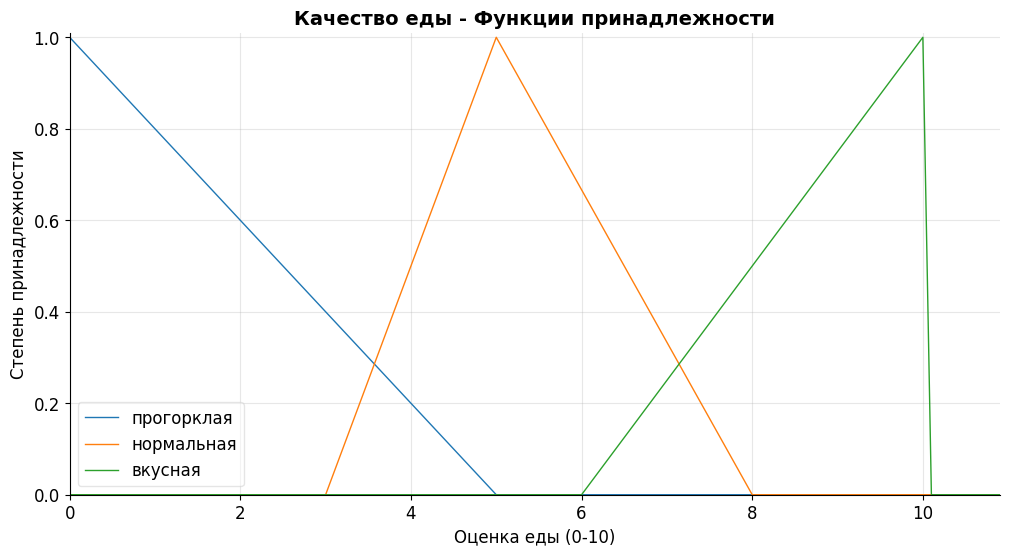

📊 График показывает, как различные оценки еды
   соотносятся с лингвистическими термами


In [9]:
# ЯЧЕЙКА 8: График функции принадлежности для качества еды

plt.figure(figsize=(10, 5))
food.view()
plt.title('Качество еды - Функции принадлежности', fontsize=14, fontweight='bold')
plt.xlabel('Оценка еды (0-10)', fontsize=12)
plt.ylabel('Степень принадлежности', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("📊 График показывает, как различные оценки еды")
print("   соотносятся с лингвистическими термами")

# 9: Визуализация функций принадлежности (Часть 2)

<Figure size 1000x500 with 0 Axes>

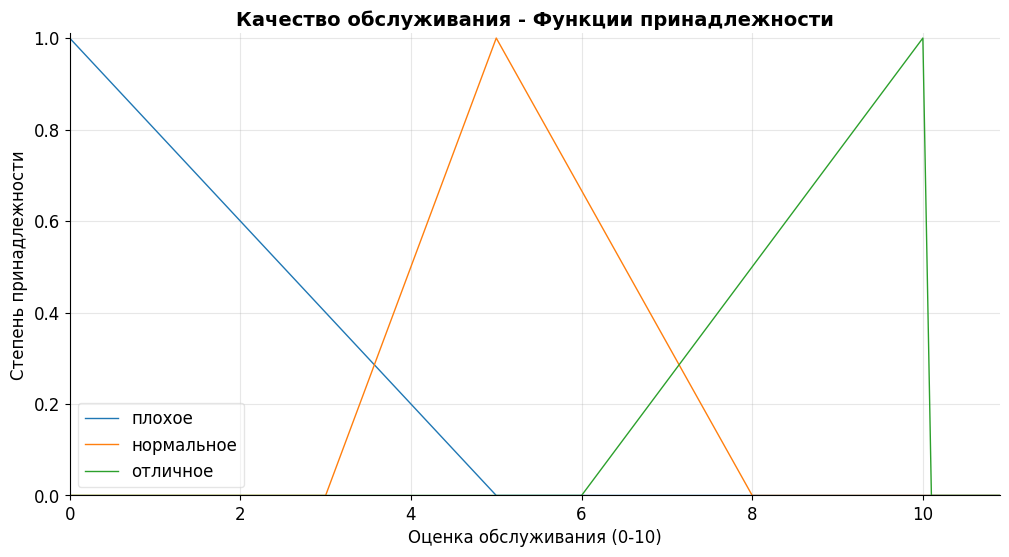

📊 Аналогично еде, обслуживание имеет три лингвистических терма


In [10]:
# ЯЧЕЙКА 9: График функции принадлежности для качества обслуживания

plt.figure(figsize=(10, 5))
service.view()
plt.title('Качество обслуживания - Функции принадлежности', fontsize=14, fontweight='bold')
plt.xlabel('Оценка обслуживания (0-10)', fontsize=12)
plt.ylabel('Степень принадлежности', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("📊 Аналогично еде, обслуживание имеет три лингвистических терма")

# 10: Визуализация функций принадлежности (Часть 3)

<Figure size 1000x500 with 0 Axes>

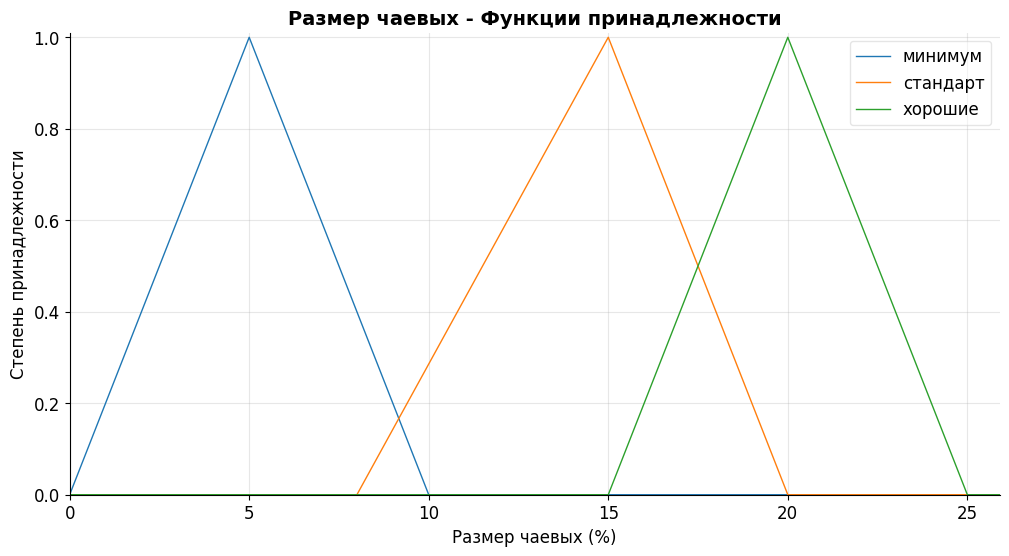

📊 Выходная переменная также имеет три возможных значения


In [11]:
# ЯЧЕЙКА 10: График функции принадлежности для чаевых

plt.figure(figsize=(10, 5))
tip.view()
plt.title('Размер чаевых - Функции принадлежности', fontsize=14, fontweight='bold')
plt.xlabel('Размер чаевых (%)', fontsize=12)
plt.ylabel('Степень принадлежности', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("📊 Выходная переменная также имеет три возможных значения")

# 11: Создание правил нечеткой логики

In [12]:
# ЯЧЕЙКА 11: Определение базы правил

# Правило 1: Если еда прогорклая, то чаевые минимум
rule1 = ctrl.Rule(food['прогорклая'], tip['минимум'])

# Правило 2: Если обслуживание плохое, то чаевые минимум
rule2 = ctrl.Rule(service['плохое'], tip['минимум'])

# Правило 3: Если еда нормальная И обслуживание нормальное, то чаевые стандарт
rule3 = ctrl.Rule(food['нормальная'] & service['нормальное'], tip['стандарт'])

# Правило 4: Если еда вкусная И обслуживание отличное, то чаевые хорошие
rule4 = ctrl.Rule(food['вкусная'] & service['отличное'], tip['хорошие'])

# Правило 5: Если еда вкусная И обслуживание нормальное, то чаевые стандарт
rule5 = ctrl.Rule(food['вкусная'] & service['нормальное'], tip['стандарт'])

# Правило 6: Если еда нормальная И обслуживание отличное, то чаевые стандарт
rule6 = ctrl.Rule(food['нормальная'] & service['отличное'], tip['стандарт'])

print("✅ Создано 6 правил нечеткой логики")
print("\n📋 Список правил:")
print("1. Если еда прогорклая → чаевые минимум")
print("2. Если обслуживание плохое → чаевые минимум")
print("3. Если еда нормальная И обслуживание нормальное → чаевые стандарт")
print("4. Если еда вкусная И обслуживание отличное → чаевые хорошие")
print("5. Если еда вкусная И обслуживание нормальное → чаевые стандарт")
print("6. Если еда нормальная И обслуживание отличное → чаевые стандарт")

✅ Создано 6 правил нечеткой логики

📋 Список правил:
1. Если еда прогорклая → чаевые минимум
2. Если обслуживание плохое → чаевые минимум
3. Если еда нормальная И обслуживание нормальное → чаевые стандарт
4. Если еда вкусная И обслуживание отличное → чаевые хорошие
5. Если еда вкусная И обслуживание нормальное → чаевые стандарт
6. Если еда нормальная И обслуживание отличное → чаевые стандарт


#  12: Таблица правил

In [13]:
# ЯЧЕЙКА 12: Отображение правил в виде таблицы

# Создаем DataFrame для наглядного представления правил
rules_data = {
    'Правило': [1, 2, 3, 4, 5, 6],
    'Еда': ['прогорклая', 'любая', 'нормальная', 'вкусная', 'вкусная', 'нормальная'],
    'Обслуживание': ['любое', 'плохое', 'нормальное', 'отличное', 'нормальное', 'отличное'],
    'Оператор': ['-', '-', 'И', 'И', 'И', 'И'],
    'Чаевые': ['минимум (5%)', 'минимум (5%)', 'стандарт (15%)', 'хорошие (20%)', 'стандарт (15%)', 'стандарт (15%)']
}

rules_df = pd.DataFrame(rules_data)
display(rules_df)

print("📊 Таблица наглядно показывает все правила")
print("   - Знак '-' означает 'любое значение'")
print("   - 'И' означает логическое И между условиями")

,Правило,Еда,Обслуживание,Оператор,Чаевые
0,1,прогорклая,любое,-,минимум (5%)
1,2,любая,плохое,-,минимум (5%)
2,3,нормальная,нормальное,И,стандарт (15%)
3,4,вкусная,отличное,И,хорошие (20%)
4,5,вкусная,нормальное,И,стандарт (15%)
5,6,нормальная,отличное,И,стандарт (15%)


📊 Таблица наглядно показывает все правила
   - Знак '-' означает 'любое значение'
   - 'И' означает логическое И между условиями


# 13: Создание системы управления

In [14]:
# ЯЧЕЙКА 13: Сборка системы нечеткого вывода

# Создаем систему управления из всех правил
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6])

# Создаем симулятор для этой системы
tipping_sim = ctrl.ControlSystemSimulation(tipping_ctrl)

print("✅ Система нечеткого вывода успешно создана!")
print("   Теперь можно подавать входные значения и получать результат")

✅ Система нечеткого вывода успешно создана!
   Теперь можно подавать входные значения и получать результат


# 14: Пример 1 - Плохой сценарий

ТЕСТ 1: Плохая еда и плохое обслуживание

📥 Входные данные:
   - Качество еды: 2/10
   - Качество обслуживания: 2/10

📤 Результат:
   - Размер чаевых: 5.0%
   - Рекомендация: Минимальные чаевые (5%)


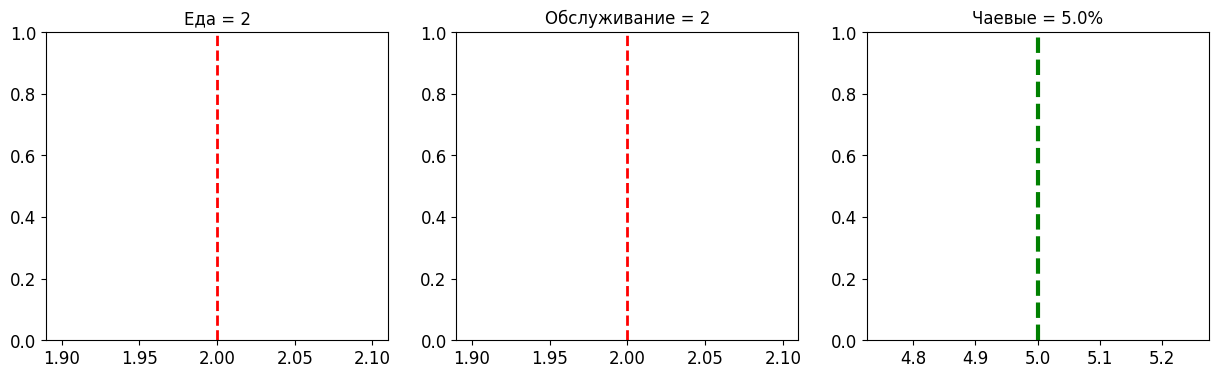

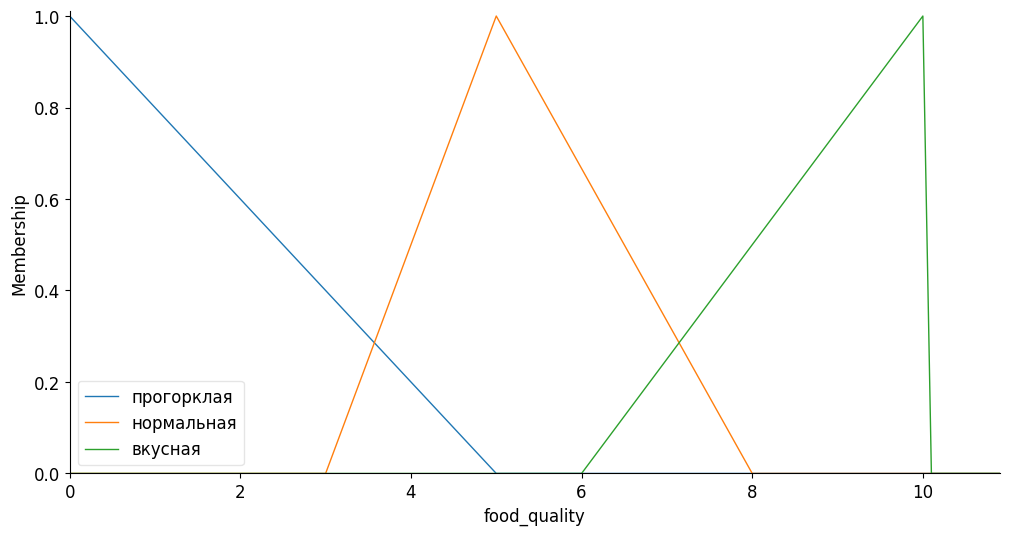

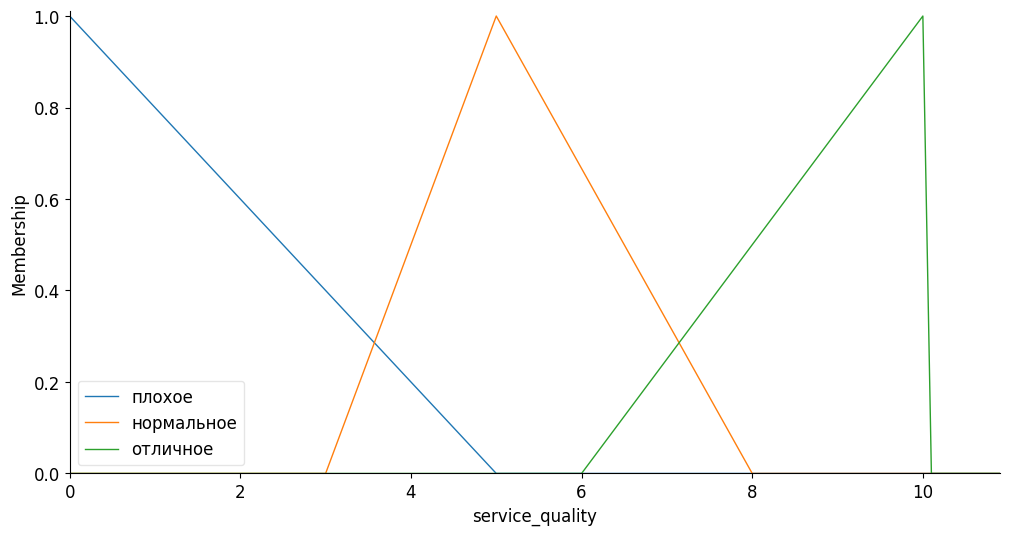

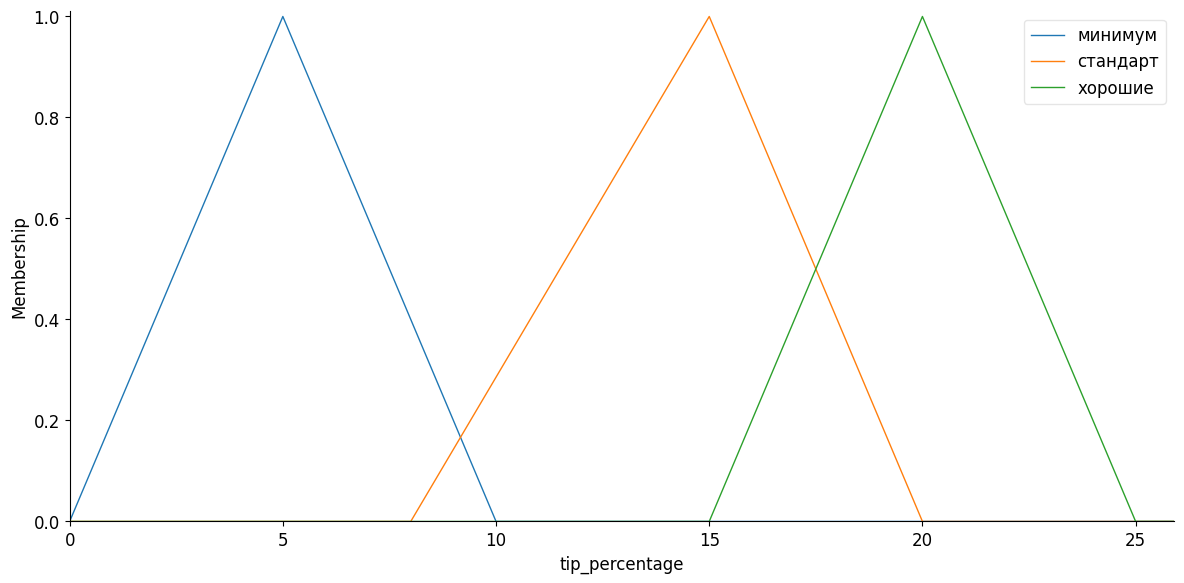

In [15]:
# ЯЧЕЙКА 14: Тест 1 - Все плохо

print("=" * 60)
print("ТЕСТ 1: Плохая еда и плохое обслуживание")
print("=" * 60)

# Задаем входные значения
food_value = 2  # прогорклая еда
service_value = 2  # плохое обслуживание

print(f"\n📥 Входные данные:")
print(f"   - Качество еды: {food_value}/10")
print(f"   - Качество обслуживания: {service_value}/10")

# Передаем значения в систему
tipping_sim.input['food_quality'] = food_value
tipping_sim.input['service_quality'] = service_value

# Вычисляем результат
tipping_sim.compute()

# Получаем результат
tip_result = tipping_sim.output['tip_percentage']

print(f"\n📤 Результат:")
print(f"   - Размер чаевых: {tip_result:.1f}%")
print(f"   - Рекомендация: Минимальные чаевые (5%)")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График для еды
food.view(ax=axes[0])
axes[0].axvline(x=food_value, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'Еда = {food_value}', fontsize=12)

# График для обслуживания
service.view(ax=axes[1])
axes[1].axvline(x=service_value, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'Обслуживание = {service_value}', fontsize=12)

# График для чаевых
tip.view(ax=axes[2])
axes[2].axvline(x=tip_result, color='green', linestyle='--', linewidth=3)
axes[2].set_title(f'Чаевые = {tip_result:.1f}%', fontsize=12)

plt.tight_layout()
plt.show()

# 15: Пример 2 - Отличный сценарий

ТЕСТ 2: Отличная еда и отличное обслуживание

📥 Входные данные:
   - Качество еды: 9/10
   - Качество обслуживания: 9/10

📤 Результат:
   - Размер чаевых: 20.0%
   - Рекомендация: Хорошие чаевые (20%)


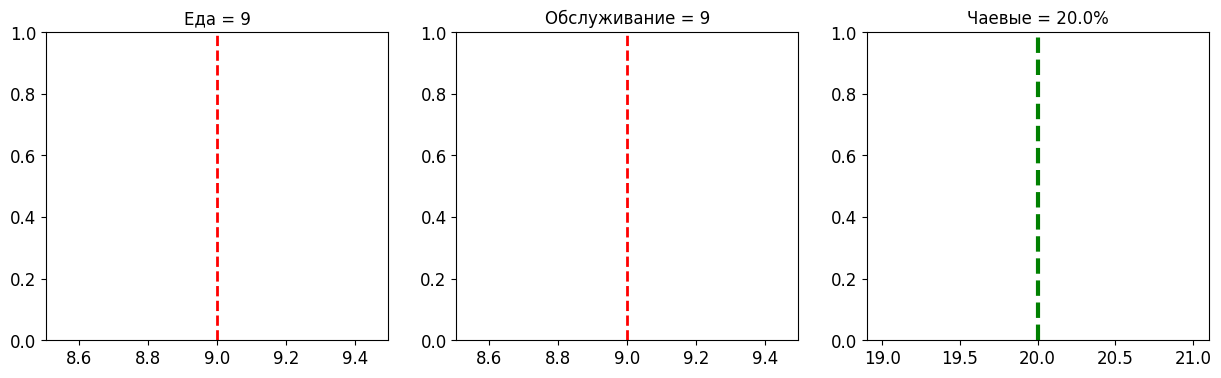

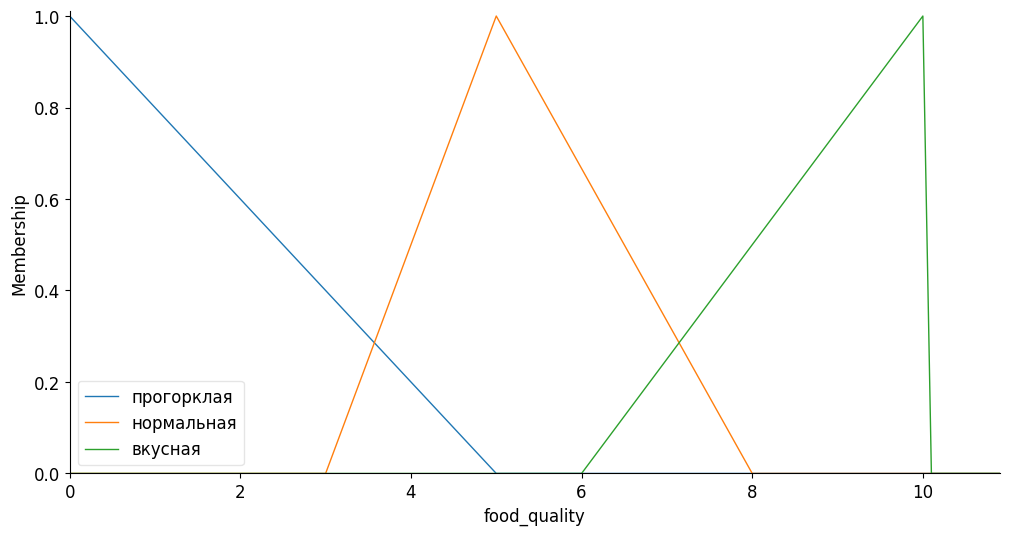

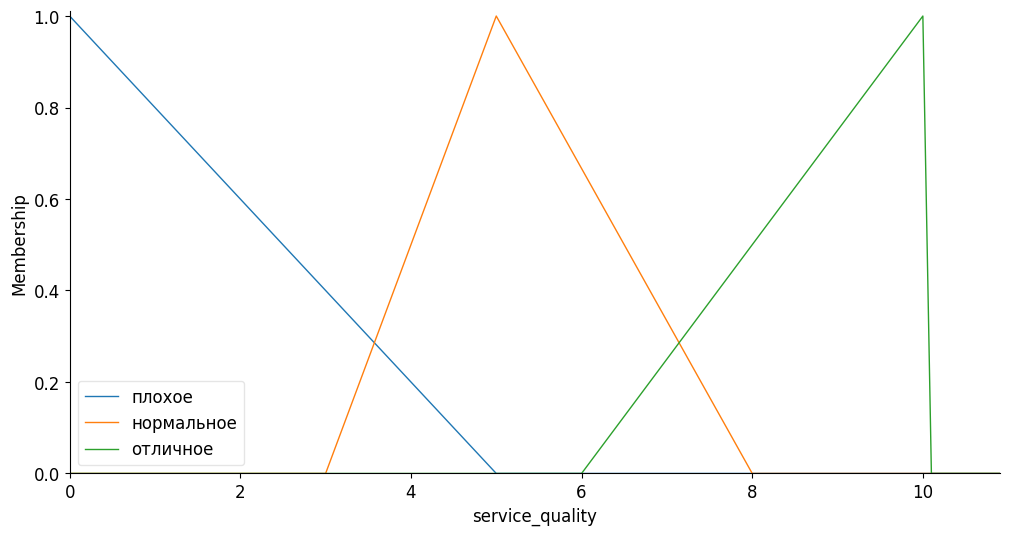

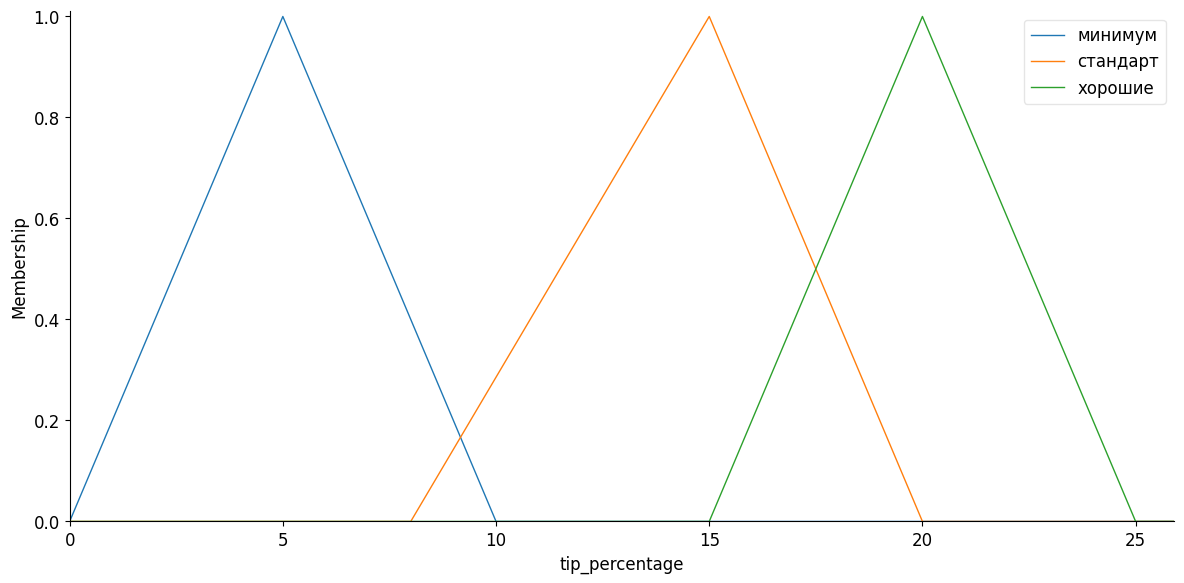

In [16]:
# ЯЧЕЙКА 15: Тест 2 - Все отлично

print("=" * 60)
print("ТЕСТ 2: Отличная еда и отличное обслуживание")
print("=" * 60)

# Задаем входные значения
food_value = 9  # вкусная еда
service_value = 9  # отличное обслуживание

print(f"\n📥 Входные данные:")
print(f"   - Качество еды: {food_value}/10")
print(f"   - Качество обслуживания: {service_value}/10")

# Передаем значения в систему
tipping_sim.input['food_quality'] = food_value
tipping_sim.input['service_quality'] = service_value

# Вычисляем результат
tipping_sim.compute()

# Получаем результат
tip_result = tipping_sim.output['tip_percentage']

print(f"\n📤 Результат:")
print(f"   - Размер чаевых: {tip_result:.1f}%")
print(f"   - Рекомендация: Хорошие чаевые (20%)")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График для еды
food.view(ax=axes[0])
axes[0].axvline(x=food_value, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'Еда = {food_value}', fontsize=12)

# График для обслуживания
service.view(ax=axes[1])
axes[1].axvline(x=service_value, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'Обслуживание = {service_value}', fontsize=12)

# График для чаевых
tip.view(ax=axes[2])
axes[2].axvline(x=tip_result, color='green', linestyle='--', linewidth=3)
axes[2].set_title(f'Чаевые = {tip_result:.1f}%', fontsize=12)

plt.tight_layout()
plt.show()

# 16: Пример 3 - Компромиссный сценарий

ТЕСТ 3: Компромиссный вариант

📥 Входные данные:
   - Качество еды: 7/10
   - Качество обслуживания: 8/10

📤 Результат:
   - Размер чаевых: 16.3%
   - Рекомендация: Стандартные чаевые (15%)


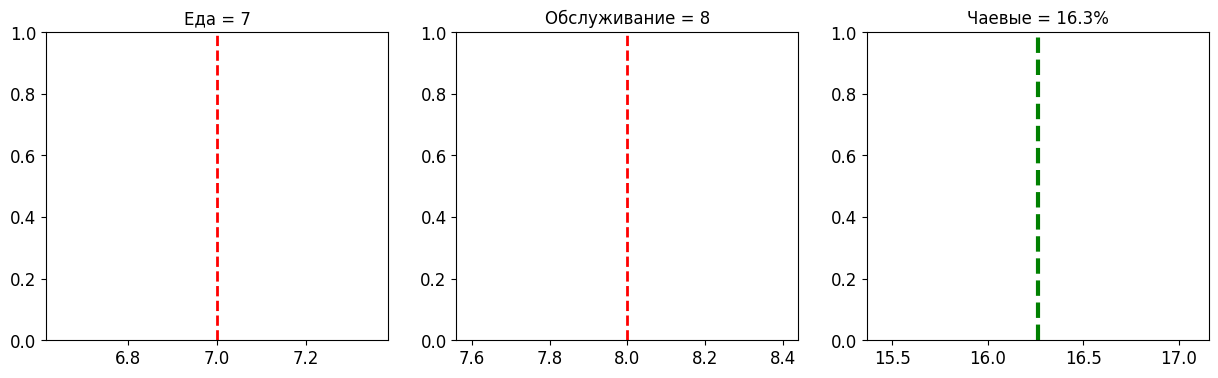

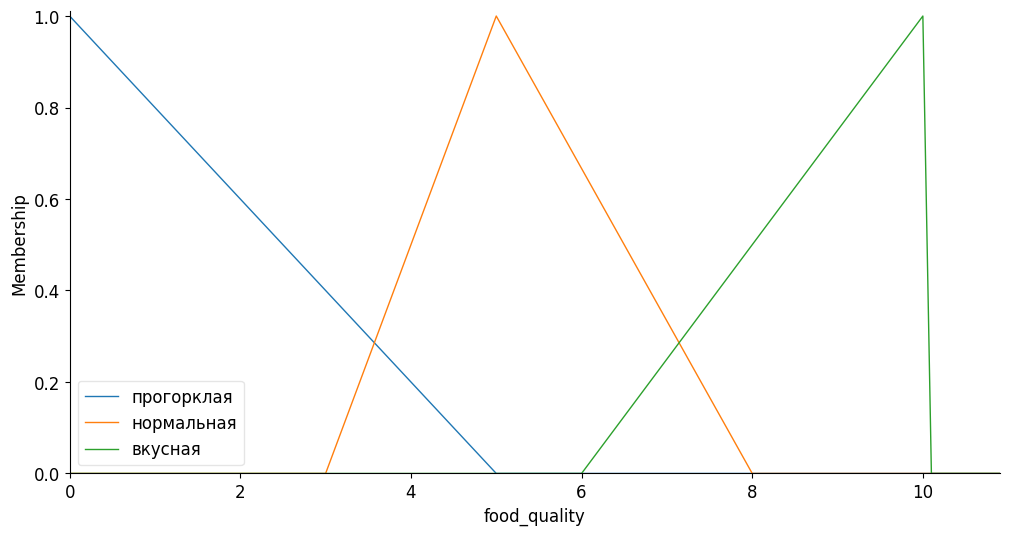

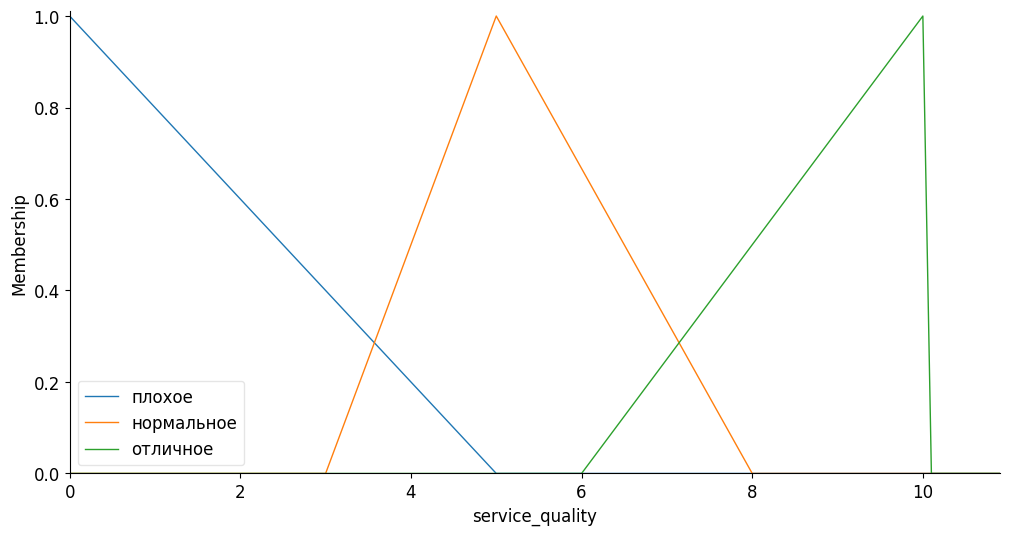

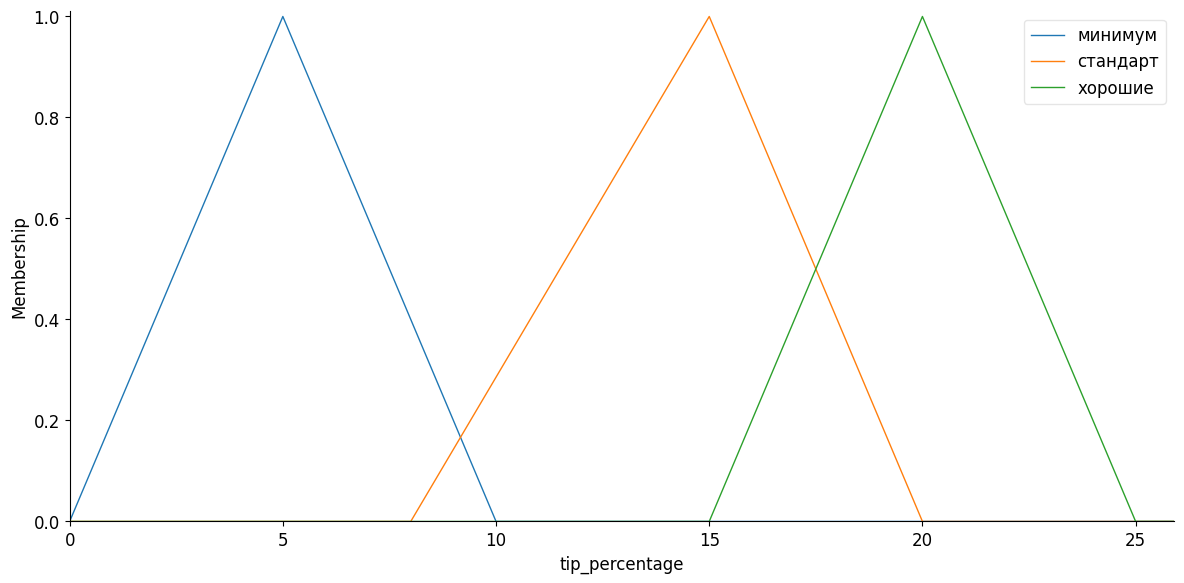

In [17]:
# ЯЧЕЙКА 16: Тест 3 - Компромиссный вариант

print("=" * 60)
print("ТЕСТ 3: Компромиссный вариант")
print("=" * 60)

# Задаем входные значения
food_value = 7  # нормальная/вкусная еда
service_value = 8  # хорошее обслуживание

print(f"\n📥 Входные данные:")
print(f"   - Качество еды: {food_value}/10")
print(f"   - Качество обслуживания: {service_value}/10")

# Передаем значения в систему
tipping_sim.input['food_quality'] = food_value
tipping_sim.input['service_quality'] = service_value

# Вычисляем результат
tipping_sim.compute()

# Получаем результат
tip_result = tipping_sim.output['tip_percentage']

print(f"\n📤 Результат:")
print(f"   - Размер чаевых: {tip_result:.1f}%")
print(f"   - Рекомендация: Стандартные чаевые (15%)")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График для еды
food.view(ax=axes[0])
axes[0].axvline(x=food_value, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'Еда = {food_value}', fontsize=12)

# График для обслуживания
service.view(ax=axes[1])
axes[1].axvline(x=service_value, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'Обслуживание = {service_value}', fontsize=12)

# График для чаевых
tip.view(ax=axes[2])
axes[2].axvline(x=tip_result, color='green', linestyle='--', linewidth=3)
axes[2].set_title(f'Чаевые = {tip_result:.1f}%', fontsize=12)

plt.tight_layout()
plt.show()

# 17: Детальный разбор процесса нечеткого вывода

🎬 Демонстрация полного процесса нечеткого вывода

🔍 Анализ для Еда=8, Обслуживание=7
--------------------------------------------------

📊 Степень принадлежности входных значений:
   Еда:
      - прогорклая: 0.000
      - нормальная: 0.000
      - вкусная: 0.500
   Обслуживание:
      - плохое: 0.000
      - нормальное: 0.333
      - отличное: 0.250

🎯 Активация правил:
   П1 (прогорклая еда): 0.000
   П2 (плохое обслуживание): 0.000
   П3 (нормальная еда И нормальное обслуживание): 0.000
   П4 (вкусная еда И отличное обслуживание): 0.250
   П5 (вкусная еда И нормальное обслуживание): 0.333
   П6 (нормальная еда И отличное обслуживание): 0.000

💡 Итоговый результат: 16.3% чаевых


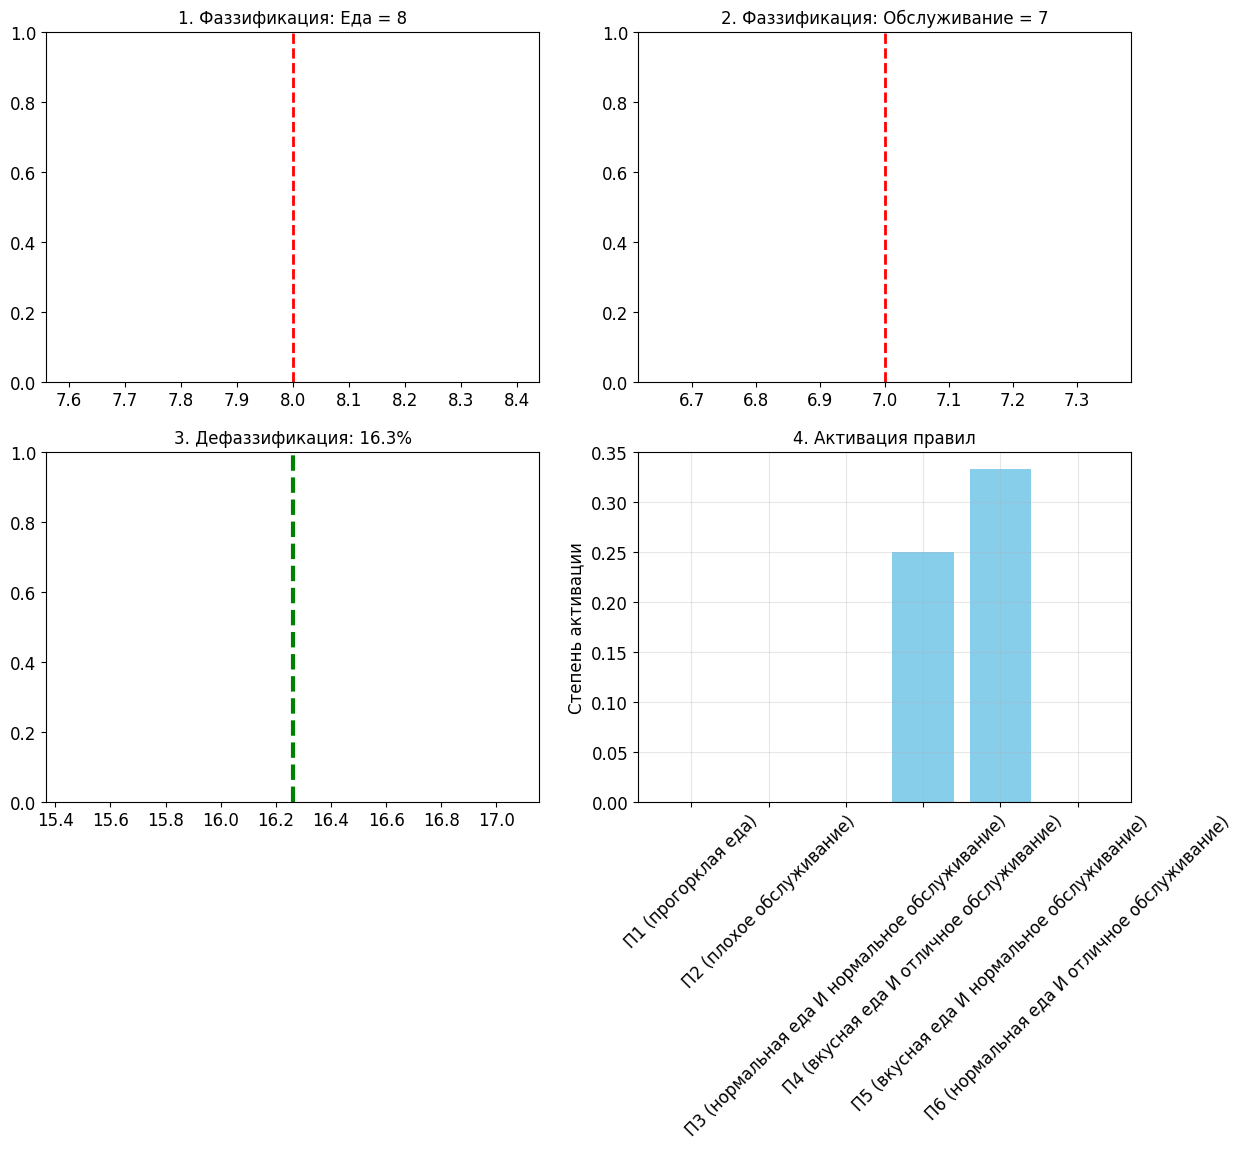

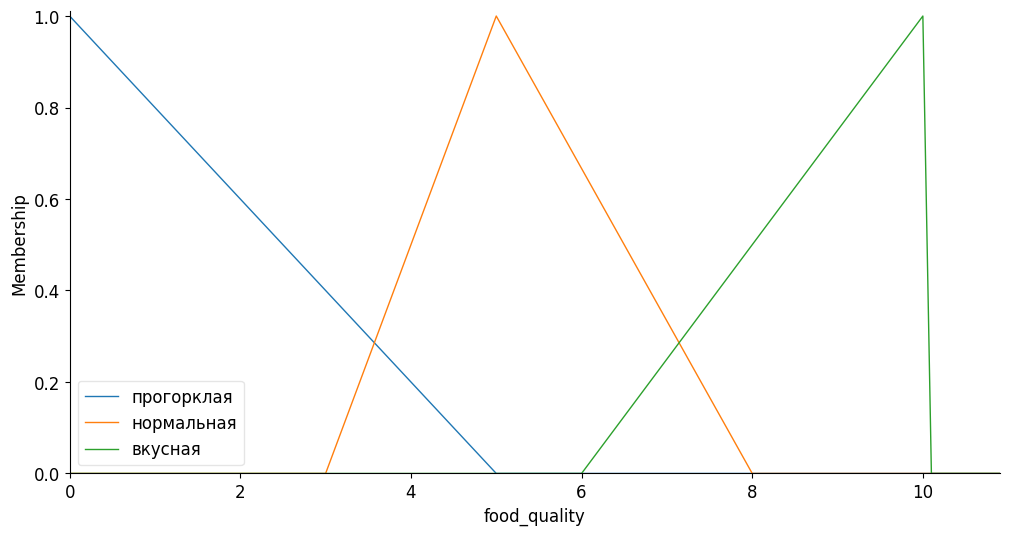

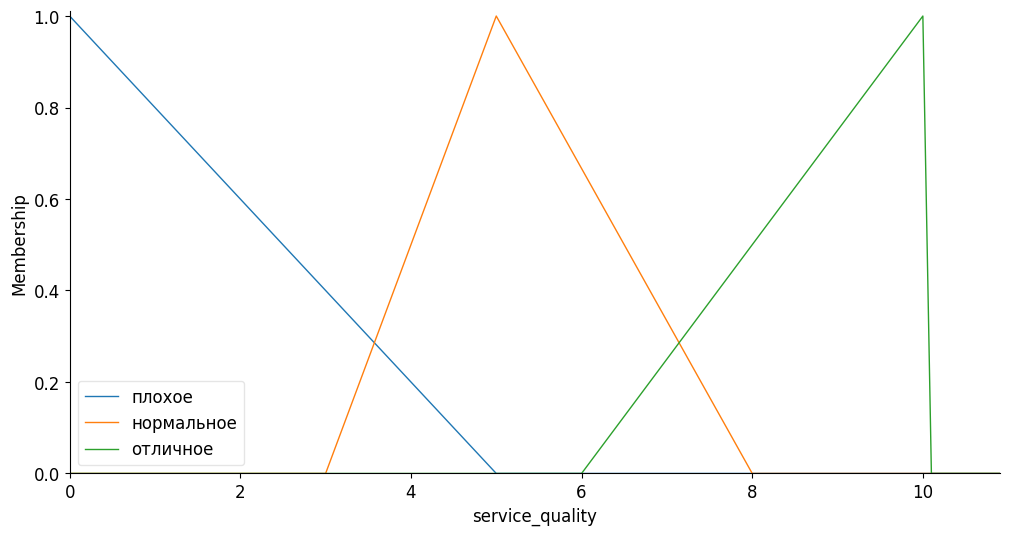

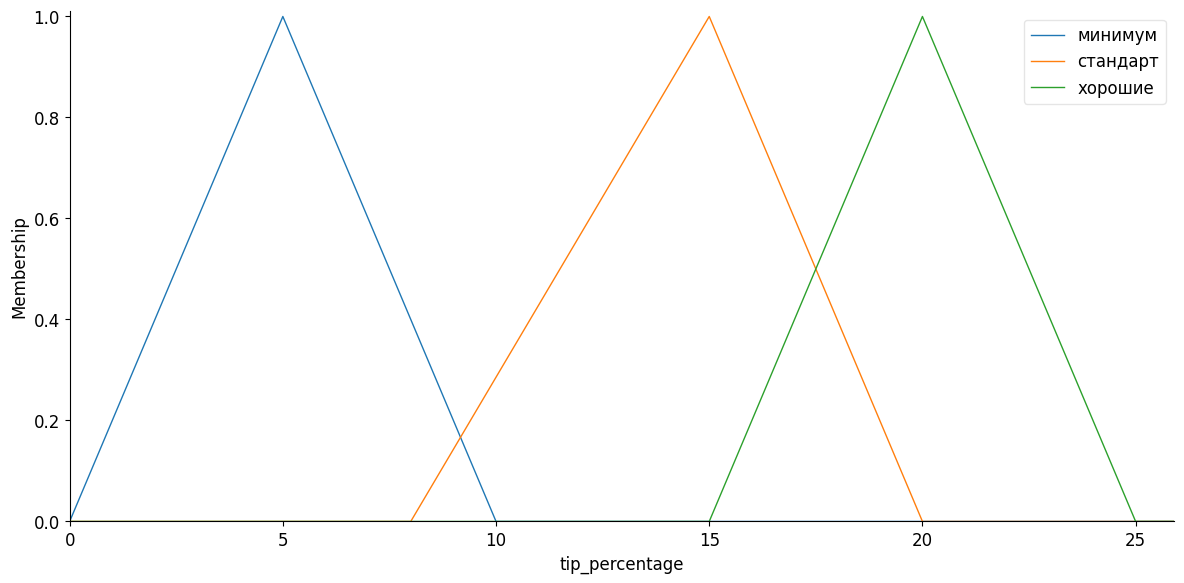

np.float64(16.260994349803138)

In [18]:
# ЯЧЕЙКА 17: Детальная визуализация процесса

def visualize_fuzzy_process(food_val, service_val):
    """Визуализация каждого шага нечеткого вывода"""
    
    print(f"\n🔍 Анализ для Еда={food_val}, Обслуживание={service_val}")
    print("-" * 50)
    
    # Сброс симуляции
    tipping_sim.input['food_quality'] = food_val
    tipping_sim.input['service_quality'] = service_val
    
    # Вычисляем степени активации для каждого терма
    food_activation = {
        'прогорклая': fuzz.interp_membership(food.universe, food['прогорклая'].mf, food_val),
        'нормальная': fuzz.interp_membership(food.universe, food['нормальная'].mf, food_val),
        'вкусная': fuzz.interp_membership(food.universe, food['вкусная'].mf, food_val)
    }
    
    service_activation = {
        'плохое': fuzz.interp_membership(service.universe, service['плохое'].mf, service_val),
        'нормальное': fuzz.interp_membership(service.universe, service['нормальное'].mf, service_val),
        'отличное': fuzz.interp_membership(service.universe, service['отличное'].mf, service_val)
    }
    
    print("\n📊 Степень принадлежности входных значений:")
    print(f"   Еда:")
    for term, val in food_activation.items():
        print(f"      - {term}: {val:.3f}")
    print(f"   Обслуживание:")
    for term, val in service_activation.items():
        print(f"      - {term}: {val:.3f}")
    
    # Вычисляем активацию правил
    rule_activations = {
        'П1 (прогорклая еда)': food_activation['прогорклая'],
        'П2 (плохое обслуживание)': service_activation['плохое'],
        'П3 (нормальная еда И нормальное обслуживание)': min(food_activation['нормальная'], service_activation['нормальное']),
        'П4 (вкусная еда И отличное обслуживание)': min(food_activation['вкусная'], service_activation['отличное']),
        'П5 (вкусная еда И нормальное обслуживание)': min(food_activation['вкусная'], service_activation['нормальное']),
        'П6 (нормальная еда И отличное обслуживание)': min(food_activation['нормальная'], service_activation['отличное'])
    }
    
    print("\n🎯 Активация правил:")
    for rule, activation in rule_activations.items():
        print(f"   {rule}: {activation:.3f}")
    
    # Вычисляем результат
    tipping_sim.compute()
    tip_result = tipping_sim.output['tip_percentage']
    
    print(f"\n💡 Итоговый результат: {tip_result:.1f}% чаевых")
    
    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Функции принадлежности для еды
    food.view(ax=axes[0, 0])
    axes[0, 0].axvline(x=food_val, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_title(f'1. Фаззификация: Еда = {food_val}', fontsize=12)
    
    # Функции принадлежности для обслуживания
    service.view(ax=axes[0, 1])
    axes[0, 1].axvline(x=service_val, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_title(f'2. Фаззификация: Обслуживание = {service_val}', fontsize=12)
    
    # Результат
    tip.view(ax=axes[1, 0])
    axes[1, 0].axvline(x=tip_result, color='green', linestyle='--', linewidth=3)
    axes[1, 0].set_title(f'3. Дефаззификация: {tip_result:.1f}%', fontsize=12)
    
    # Активация правил
    rules_list = list(rule_activations.keys())
    activations = list(rule_activations.values())
    axes[1, 1].bar(rules_list, activations, color='skyblue')
    axes[1, 1].set_title('4. Активация правил', fontsize=12)
    axes[1, 1].set_ylabel('Степень активации')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return tip_result

# Демонстрация процесса
print("🎬 Демонстрация полного процесса нечеткого вывода")
visualize_fuzzy_process(8, 7)

# 18: 3D поверхность решений

🗺️ Построение 3D поверхности решений...


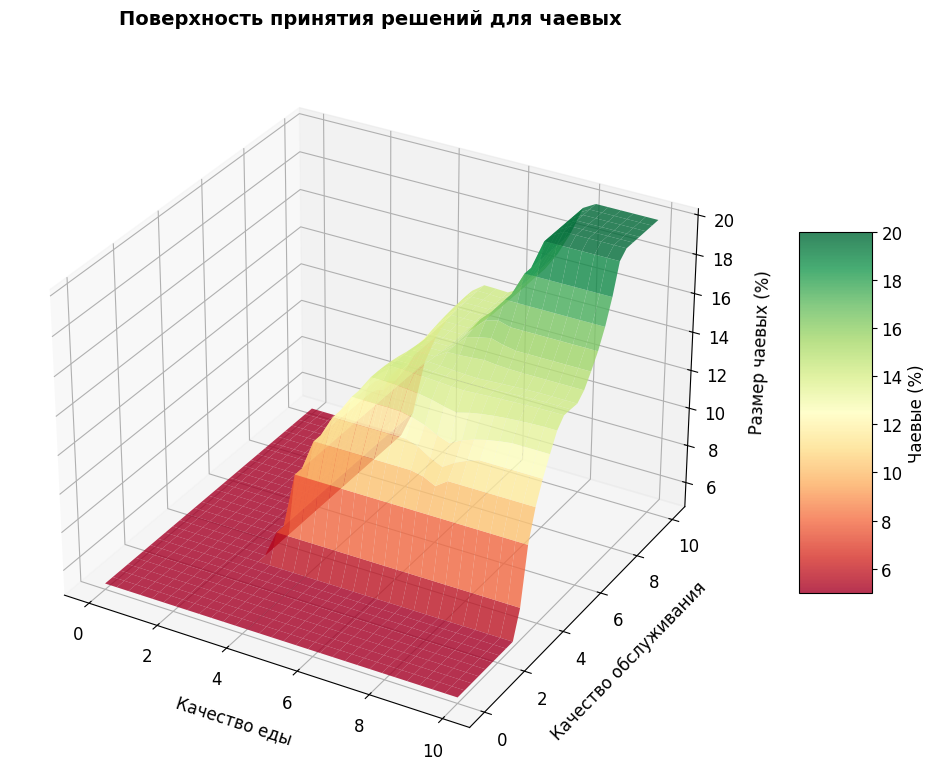


📈 Интерпретация графика:
   - Красные области: маленькие чаевые (5-10%)
   - Желтые области: средние чаевые (10-15%)
   - Зеленые области: большие чаевые (15-20%)
   - Видно, что наилучшие чаевые - в правом верхнем углу (хорошая еда и обслуживание)


In [19]:
# ЯЧЕЙКА 18: Создание 3D поверхности зависимости чаевых

print("🗺️ Построение 3D поверхности решений...")

# Создаем сетку для 3D графика
food_vals = np.linspace(0, 10, 30)
service_vals = np.linspace(0, 10, 30)
tip_vals = np.zeros((len(food_vals), len(service_vals)))

# Заполняем матрицу результатов
for i, f in enumerate(food_vals):
    for j, s in enumerate(service_vals):
        tipping_sim.input['food_quality'] = f
        tipping_sim.input['service_quality'] = s
        tipping_sim.compute()
        tip_vals[i, j] = tipping_sim.output['tip_percentage']

# Создаем 3D график
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Создаем поверхность
X, Y = np.meshgrid(food_vals, service_vals)
surf = ax.plot_surface(X, Y, tip_vals.T, cmap='RdYlGn', alpha=0.8)

# Настройка графика
ax.set_xlabel('Качество еды', fontsize=12, labelpad=10)
ax.set_ylabel('Качество обслуживания', fontsize=12, labelpad=10)
ax.set_zlabel('Размер чаевых (%)', fontsize=12, labelpad=10)
ax.set_title('Поверхность принятия решений для чаевых', fontsize=14, fontweight='bold', pad=20)

# Добавляем цветовую шкалу
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Чаевые (%)')

plt.tight_layout()
plt.show()

print("\n📈 Интерпретация графика:")
print("   - Красные области: маленькие чаевые (5-10%)")
print("   - Желтые области: средние чаевые (10-15%)")
print("   - Зеленые области: большие чаевые (15-20%)")
print("   - Видно, что наилучшие чаевые - в правом верхнем углу (хорошая еда и обслуживание)")

# 19: Таблица тестовых сценариев

In [20]:
# ЯЧЕЙКА 19: Тестирование различных комбинаций

print("📊 Тестирование различных сценариев...")
print("=" * 60)

# Список тестовых сценариев
test_cases = [
    (1, 1, "Все ужасно"),
    (2, 8, "Еда плохая, обслуживание отличное"),
    (8, 2, "Еда отличная, обслуживание плохое"),
    (5, 5, "Средний вариант"),
    (9, 6, "Еда отличная, обслуживание среднее"),
    (6, 9, "Еда средняя, обслуживание отличное"),
    (10, 10, "Максимум везде"),
    (0, 0, "Минимум везде")
]

# Собираем результаты
results = []
for food_val, service_val, desc in test_cases:
    tipping_sim.input['food_quality'] = food_val
    tipping_sim.input['service_quality'] = service_val
    tipping_sim.compute()
    tip_val = tipping_sim.output['tip_percentage']
    
    # Определяем категорию
    if tip_val < 10:
        category = "😞 Минимум (5%)"
    elif tip_val < 18:
        category = "😐 Стандарт (15%)"
    else:
        category = "😊 Хорошие (20%)"
    
    results.append({
        'Сценарий': desc,
        '🍝 Еда': food_val,
        '👨‍🍳 Обслуживание': service_val,
        '💰 Чаевые (%)': f"{tip_val:.1f}",
        '📝 Категория': category
    })

# Создаем и отображаем таблицу
results_df = pd.DataFrame(results)
display(results_df)

print("\n💡 Анализ результатов:")
print("   - Худший случай (еда=1, сервис=1): минимальные чаевые")
print("   - Лучший случай (еда=10, сервис=10): максимальные чаевые")
print("   - Компромиссные варианты дают средние значения")

📊 Тестирование различных сценариев...


,Сценарий,🍝 Еда,👨‍🍳 Обслуживание,💰 Чаевые (%),📝 Категория
0,Все ужасно,1,1,5.0,😞 Минимум (5%)
1,"Еда плохая, обслуживание отличное",2,8,5.0,😞 Минимум (5%)
2,"Еда отличная, обслуживание плохое",8,2,5.0,😞 Минимум (5%)
3,Средний вариант,5,5,14.3,😐 Стандарт (15%)
4,"Еда отличная, обслуживание среднее",9,6,14.3,😐 Стандарт (15%)
5,"Еда средняя, обслуживание отличное",6,9,14.3,😐 Стандарт (15%)
6,Максимум везде,10,10,20.0,😊 Хорошие (20%)
7,Минимум везде,0,0,5.0,😞 Минимум (5%)



💡 Анализ результатов:
   - Худший случай (еда=1, сервис=1): минимальные чаевые
   - Лучший случай (еда=10, сервис=10): максимальные чаевые
   - Компромиссные варианты дают средние значения


# 20: Схема взаимосвязей

🕸️ Построение схемы взаимосвязей...


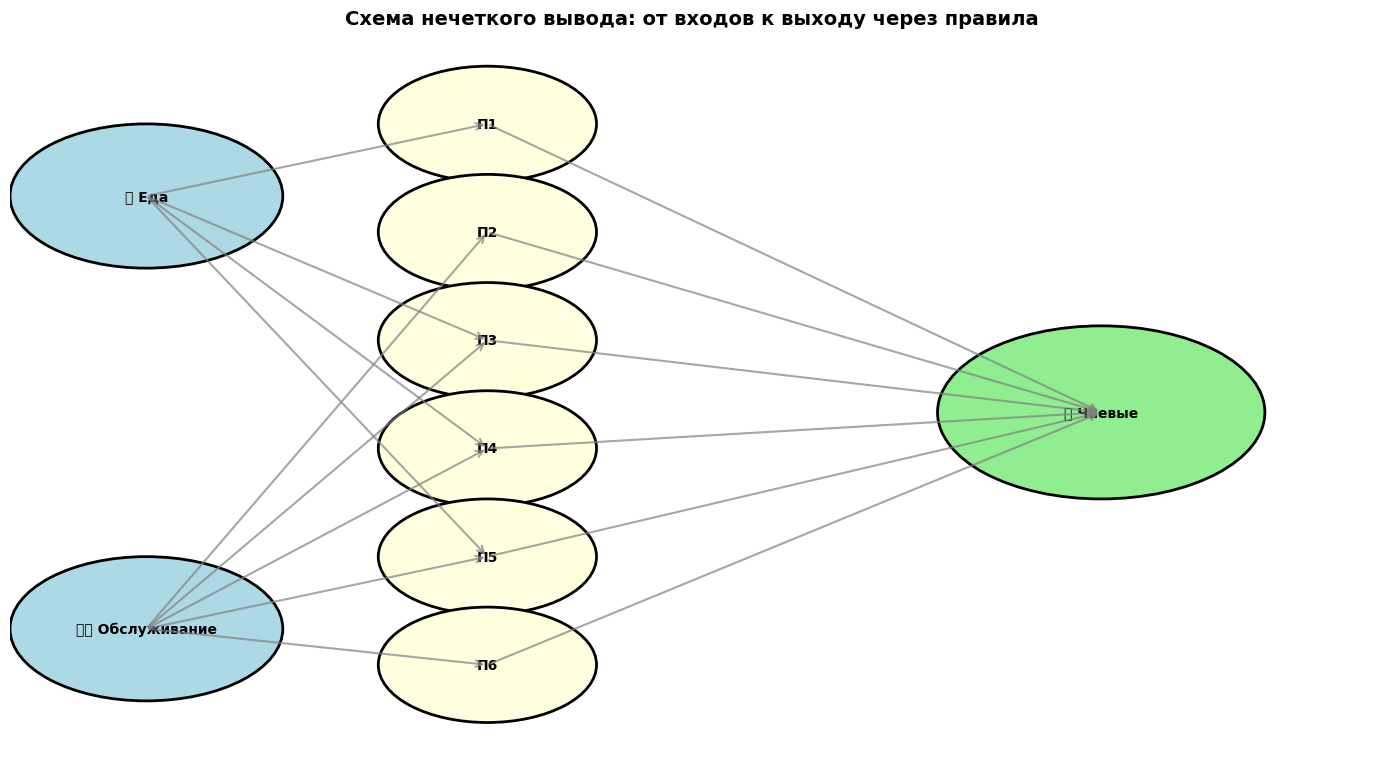


📖 Легенда:
   🔵 Синие узлы - входные переменные
   🟡 Желтые узлы - правила нечеткой логики
   🟢 Зеленый узел - выходная переменная
   Стрелки показывают поток данных

📋 Правила:
   П1: Если еда прогорклая → чаевые минимум
   П2: Если обслуживание плохое → чаевые минимум
   П3: Если еда нормальная И обслуживание нормальное → чаевые стандарт
   П4: Если еда вкусная И обслуживание отличное → чаевые хорошие
   П5: Если еда вкусная И обслуживание нормальное → чаевые стандарт
   П6: Если еда нормальная И обслуживание отличное → чаевые стандарт


In [22]:
# ЯЧЕЙКА 20: Визуализация схемы нечеткого вывода (ИСПРАВЛЕНА)

print("🕸️ Построение схемы взаимосвязей...")

# Создаем схему правил
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

# Определяем позиции узлов (добавили П6)
nodes = {
    '🍝 Еда': (0.1, 0.8),
    '👨‍🍳 Обслуживание': (0.1, 0.2),
    'П1': (0.35, 0.9),
    'П2': (0.35, 0.75),
    'П3': (0.35, 0.6),
    'П4': (0.35, 0.45),
    'П5': (0.35, 0.3),
    'П6': (0.35, 0.15),  # Добавлено правило 6
    '💰 Чаевые': (0.8, 0.5)
}

# Рисуем узлы
for node, (x, y) in nodes.items():
    if 'Еда' in node or 'Обслуживание' in node:
        color = 'lightblue'
        size = 0.1
    elif 'Чаевые' in node:
        color = 'lightgreen'
        size = 0.12
    else:
        color = 'lightyellow'
        size = 0.08
    
    circle = plt.Circle((x, y), size, color=color, ec='black', linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=10, fontweight='bold')

# Рисуем связи (теперь все правила присутствуют)
edges = [
    # Связи от еды к правилам
    ('🍝 Еда', 'П1'), 
    ('🍝 Еда', 'П3'), 
    ('🍝 Еда', 'П4'), 
    ('🍝 Еда', 'П5'),
    
    # Связи от обслуживания к правилам
    ('👨‍🍳 Обслуживание', 'П2'), 
    ('👨‍🍳 Обслуживание', 'П3'), 
    ('👨‍🍳 Обслуживание', 'П4'), 
    ('👨‍🍳 Обслуживание', 'П5'), 
    ('👨‍🍳 Обслуживание', 'П6'),  # Теперь П6 существует
    
    # Связи от правил к чаевым
    ('П1', '💰 Чаевые'), 
    ('П2', '💰 Чаевые'), 
    ('П3', '💰 Чаевые'),
    ('П4', '💰 Чаевые'), 
    ('П5', '💰 Чаевые'),
    ('П6', '💰 Чаевые')  # Добавлена связь для П6
]

# Рисуем все связи
for start, end in edges:
    if start in nodes and end in nodes:  # Проверяем, что узлы существуют
        x1, y1 = nodes[start]
        x2, y2 = nodes[end]
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='gray', alpha=0.7))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Схема нечеткого вывода: от входов к выходу через правила', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n📖 Легенда:")
print("   🔵 Синие узлы - входные переменные")
print("   🟡 Желтые узлы - правила нечеткой логики")
print("   🟢 Зеленый узел - выходная переменная")
print("   Стрелки показывают поток данных")

print("\n📋 Правила:")
print("   П1: Если еда прогорклая → чаевые минимум")
print("   П2: Если обслуживание плохое → чаевые минимум")
print("   П3: Если еда нормальная И обслуживание нормальное → чаевые стандарт")
print("   П4: Если еда вкусная И обслуживание отличное → чаевые хорошие")
print("   П5: Если еда вкусная И обслуживание нормальное → чаевые стандарт")
print("   П6: Если еда нормальная И обслуживание отличное → чаевые стандарт")

# 21: Заключение

In [23]:
# ЯЧЕЙКА 21: Заключение и выводы

md("""
## 📝 Заключение

### Что мы сделали:

1. **Создали лингвистические переменные** для еды, обслуживания и чаевых
2. **Определили функции принадлежности** для каждой переменной
3. **Сформулировали правила** нечеткой логики
4. **Построили систему вывода** и протестировали её
5. **Визуализировали результаты** в 2D и 3D

### Ключевые концепции нечеткой логики:

- **Фаззификация**: преобразование четких значений в нечеткие
- **Агрегация**: объединение активированных правил
- **Дефаззификация**: получение четкого результата

### Преимущества нечеткой логики:

✅ Работает с нечеткими понятиями  
✅ Легко интерпретируется человеком  
✅ Может учитывать экспертные знания  
✅ Устойчива к неточным входным данным  

### Области применения:

- Системы управления (роботы, станки)
- Распознавание образов
- Медицинская диагностика
- Финансовое прогнозирование
- Экспертные системы

---

## 🎯 Итог

Нечеткая логика - мощный инструмент для моделирования сложных систем,
где традиционные бинарные подходы неэффективны. В нашем примере с чаевыми
мы успешно смоделировали нечеткие человеческие понятия "вкусная еда" и
"хорошее обслуживание" и получили осмысленный результат.

**Готово! 🚀**
""")

print("\n✅ Все ячейки выполнены успешно!")


## 📝 Заключение

### Что мы сделали:

1. **Создали лингвистические переменные** для еды, обслуживания и чаевых
2. **Определили функции принадлежности** для каждой переменной
3. **Сформулировали правила** нечеткой логики
4. **Построили систему вывода** и протестировали её
5. **Визуализировали результаты** в 2D и 3D

### Ключевые концепции нечеткой логики:

- **Фаззификация**: преобразование четких значений в нечеткие
- **Агрегация**: объединение активированных правил
- **Дефаззификация**: получение четкого результата

### Преимущества нечеткой логики:

✅ Работает с нечеткими понятиями  
✅ Легко интерпретируется человеком  
✅ Может учитывать экспертные знания  
✅ Устойчива к неточным входным данным  

### Области применения:

- Системы управления (роботы, станки)
- Распознавание образов
- Медицинская диагностика
- Финансовое прогнозирование
- Экспертные системы

---

## 🎯 Итог

Нечеткая логика - мощный инструмент для моделирования сложных систем,
где традиционные бинарные подходы неэффективны. В нашем примере с чаевыми
мы успешно смоделировали нечеткие человеческие понятия "вкусная еда" и
"хорошее обслуживание" и получили осмысленный результат.

**Готово! 🚀**



✅ Все ячейки выполнены успешно!


#  22: Интерактивный калькулятор

In [25]:
# ЯЧЕЙКА 22: Интерактивный калькулятор (ИСПРАВЛЕН)

try:
    from ipywidgets import interact, FloatSlider, VBox, HTML as WHTML
    from IPython.display import display
    
    print("🎮 Загрузка интерактивного калькулятора...")
    
    def interactive_tip_calculator(food_quality=7, service_quality=7):
        """Интерактивный калькулятор чаевых"""
        
        tipping_sim.input['food_quality'] = food_quality
        tipping_sim.input['service_quality'] = service_quality
        tipping_sim.compute()
        tip_result = tipping_sim.output['tip_percentage']
        
        # Создаем визуализацию
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # График для еды
        food.view(ax=axes[0])
        axes[0].axvline(x=food_quality, color='red', linestyle='--', linewidth=2)
        axes[0].set_title(f'Качество еды = {food_quality}', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Оценка еды (0-10)')
        axes[0].set_ylabel('Степень принадлежности')
        axes[0].grid(True, alpha=0.3)
        
        # График для обслуживания
        service.view(ax=axes[1])
        axes[1].axvline(x=service_quality, color='red', linestyle='--', linewidth=2)
        axes[1].set_title(f'Качество обслуживания = {service_quality}', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Оценка обслуживания (0-10)')
        axes[1].set_ylabel('Степень принадлежности')
        axes[1].grid(True, alpha=0.3)
        
        # График для чаевых
        tip.view(ax=axes[2])
        axes[2].axvline(x=tip_result, color='green', linestyle='--', linewidth=3)
        axes[2].set_title(f'Чаевые = {tip_result:.1f}%', fontsize=12, fontweight='bold')
        axes[2].set_xlabel('Размер чаевых (%)')
        axes[2].set_ylabel('Степень принадлежности')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Определяем категорию чаевых
        if tip_result < 10:
            emoji = "😞"
            category = "Минимальные чаевые (5%)"
            advice = "Стоит подумать о смене ресторана!"
            color = "red"
        elif tip_result < 18:
            emoji = "😐"
            category = "Стандартные чаевые (15%)"
            advice = "Нормально, но есть куда расти"
            color = "orange"
        else:
            emoji = "😊"
            category = "Хорошие чаевые (20%)"
            advice = "Отлично! Обслуживание на высоте!"
            color = "green"
        
        # Выводим результат в виде форматированного HTML
        display(WHTML(f"""
        <div style='background-color: #f0f0f0; padding: 20px; border-radius: 10px; margin-top: 10px; 
                     border-left: 5px solid {color};'>
            <h2>{emoji} Результат: {tip_result:.1f}% чаевых</h2>
            <p><b>📊 Категория:</b> {category}</p>
            <p><b>💰 Рекомендуемая сумма:</b> {tip_result:.1f}% от счета</p>
            <p><b>💡 Оценка:</b> {advice}</p>
            <hr>
            <p><small>⚙️ Рассчитано с использованием нечеткой логики</small></p>
        </div>
        """))
        
        return tip_result
    
    # Создаем ползунки
    food_slider = FloatSlider(
        min=0, max=10, step=0.5, value=7,
        description='🍝 Качество еды:',
        style={'description_width': 'initial'},
        layout={'width': '500px'}
    )
    
    service_slider = FloatSlider(
        min=0, max=10, step=0.5, value=7,
        description='👨‍🍳 Качество обслуживания:',
        style={'description_width': 'initial'},
        layout={'width': '500px'}
    )
    
    # Заголовок
    display(WHTML("""
    <div style='background-color: #4CAF50; color: white; padding: 10px; border-radius: 5px; margin-bottom: 20px;'>
        <h2 style='margin: 0;'>🎮 Интерактивный калькулятор чаевых</h2>
        <p style='margin: 5px 0 0 0;'>Двигайте ползунки и смотрите, как меняется результат!</p>
    </div>
    """))
    
    # Запускаем интерактивный виджет
    interact(interactive_tip_calculator, 
             food_quality=food_slider, 
             service_quality=service_slider)
    
    print("\n✅ Интерактивный калькулятор загружен!")
    print("   Попробуйте разные комбинации значений")
    
except ImportError as e:
    print(f"⚠️ Ошибка импорта: {e}")
    print("\nДля работы интерактивного калькулятора установите ipywidgets:")
    print("   pip install ipywidgets")
    print("\nИли выполните в Jupyter:")
    print("   !pip install ipywidgets")
    
except Exception as e:
    print(f"⚠️ Произошла ошибка: {e}")
    print("\nИспользуется упрощенная версия калькулятора")
    
    # Упрощенная версия без интерактивности
    def simple_calculator():
        """Упрощенный калькулятор для проверки"""
        print("\n📱 Упрощенный калькулятор чаевых")
        print("-" * 40)
        
        try:
            food_val = float(input("Введите качество еды (0-10): "))
            service_val = float(input("Введите качество обслуживания (0-10): "))
            
            tipping_sim.input['food_quality'] = food_val
            tipping_sim.input['service_quality'] = service_val
            tipping_sim.compute()
            tip_result = tipping_sim.output['tip_percentage']
            
            print(f"\n✅ Результат: {tip_result:.1f}% чаевых")
            
            if tip_result < 10:
                print("   Категория: Минимальные чаевые (5%)")
            elif tip_result < 18:
                print("   Категория: Стандартные чаевые (15%)")
            else:
                print("   Категория: Хорошие чаевые (20%)")
                
        except ValueError:
            print("❌ Ошибка: введите числовое значение")
        except Exception as e:
            print(f"❌ Ошибка: {e}")
    
    simple_calculator()

🎮 Загрузка интерактивного калькулятора...


HTML(value="\n    <div style='background-color: #4CAF50; color: white; padding: 10px; border-radius: 5px; marg…

interactive(children=(FloatSlider(value=7.0, description='🍝 Качество еды:', layout=Layout(width='500px'), max=…


✅ Интерактивный калькулятор загружен!
   Попробуйте разные комбинации значений


# Версия 22 ячейки ввода с клавиатуры:

КАЛЬКУЛЯТОР ЧАЕВЫХ

📝 Введите параметры:


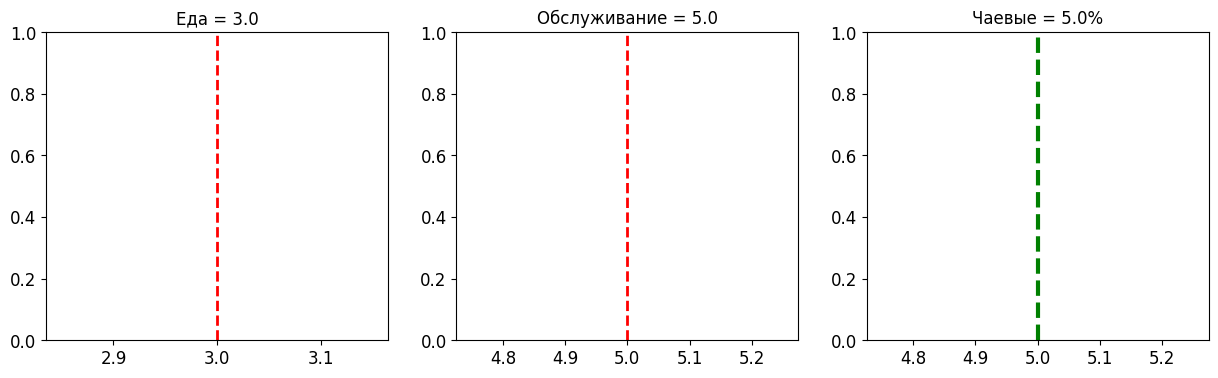

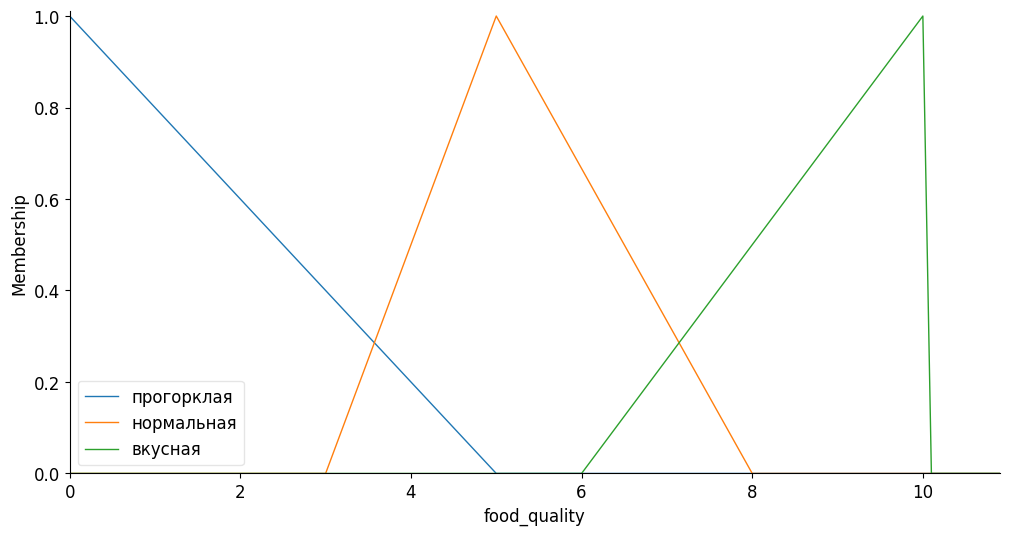

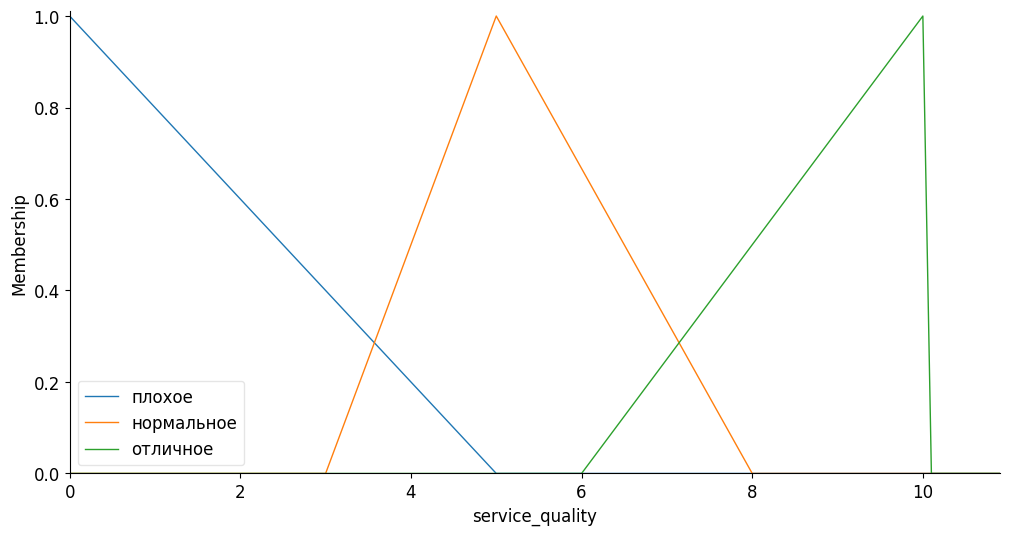

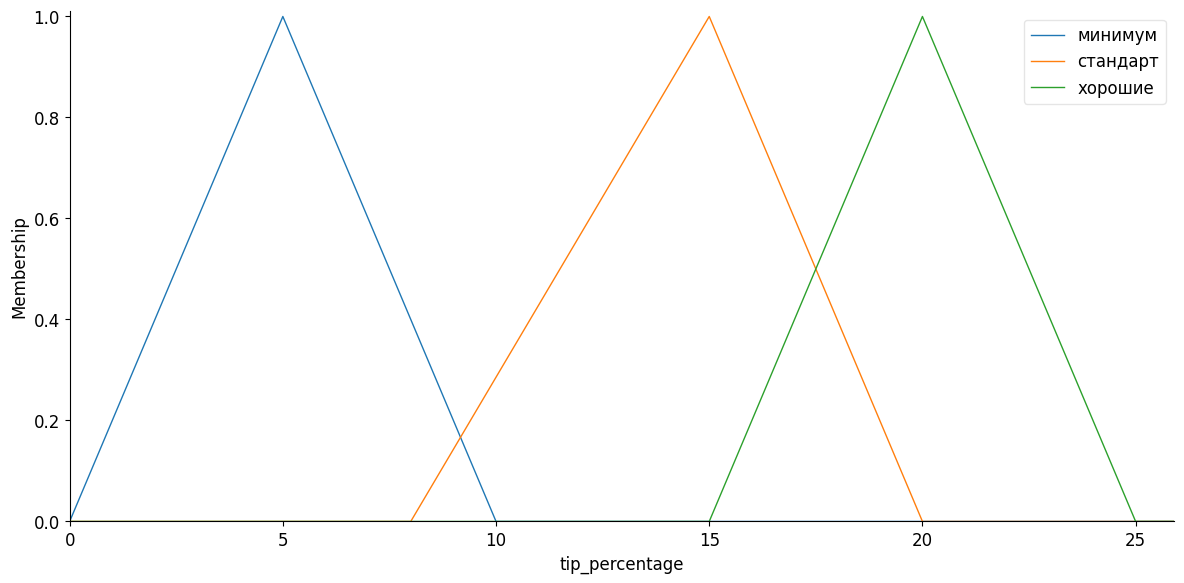


💰 РЕЗУЛЬТАТ: 5.0% чаевых
📊 Категория: Минимум (5%)
💡 Рекомендация: 😞 Обслуживание было плохим

🔄 Хотите попробовать еще раз?
   Просто запустите эту ячейку снова


In [26]:
# ЯЧЕЙКА 22: Простая версия (без интерактивности)

print("=" * 60)
print("КАЛЬКУЛЯТОР ЧАЕВЫХ")
print("=" * 60)

def calculate_tips():
    """Простой калькулятор чаевых"""
    try:
        print("\n📝 Введите параметры:")
        food_val = float(input("   Качество еды (0-10): "))
        service_val = float(input("   Качество обслуживания (0-10): "))
        
        # Проверка диапазона
        food_val = max(0, min(10, food_val))
        service_val = max(0, min(10, service_val))
        
        # Расчет
        tipping_sim.input['food_quality'] = food_val
        tipping_sim.input['service_quality'] = service_val
        tipping_sim.compute()
        tip_result = tipping_sim.output['tip_percentage']
        
        # Визуализация
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        food.view(ax=axes[0])
        axes[0].axvline(x=food_val, color='red', linestyle='--', linewidth=2)
        axes[0].set_title(f'Еда = {food_val}', fontsize=12)
        
        service.view(ax=axes[1])
        axes[1].axvline(x=service_val, color='red', linestyle='--', linewidth=2)
        axes[1].set_title(f'Обслуживание = {service_val}', fontsize=12)
        
        tip.view(ax=axes[2])
        axes[2].axvline(x=tip_result, color='green', linestyle='--', linewidth=3)
        axes[2].set_title(f'Чаевые = {tip_result:.1f}%', fontsize=12)
        
        plt.tight_layout()
        plt.show()
        
        # Результат
        print(f"\n{'='*60}")
        print(f"💰 РЕЗУЛЬТАТ: {tip_result:.1f}% чаевых")
        
        if tip_result < 10:
            print(f"📊 Категория: Минимум (5%)")
            print(f"💡 Рекомендация: 😞 Обслуживание было плохим")
        elif tip_result < 18:
            print(f"📊 Категория: Стандарт (15%)")
            print(f"💡 Рекомендация: 😐 В целом неплохо")
        else:
            print(f"📊 Категория: Хорошие (20%)")
            print(f"💡 Рекомендация: 😊 Отличное обслуживание!")
        
        print(f"{'='*60}")
        
    except ValueError:
        print("❌ Ошибка: Пожалуйста, введите числовые значения")
    except Exception as e:
        print(f"❌ Ошибка: {e}")

# Запуск калькулятора
calculate_tips()

# Добавляем возможность многократного использования
print("\n🔄 Хотите попробовать еще раз?")
print("   Просто запустите эту ячейку снова")

# полностью автоматический режим без ввода с клавиатуры:



ДЕМОНСТРАЦИЯ РАБОТЫ КАЛЬКУЛЯТОРА

📌 Плохой сценарий:
   Еда = 2, Обслуживание = 2
   → Чаевые: 5.0%


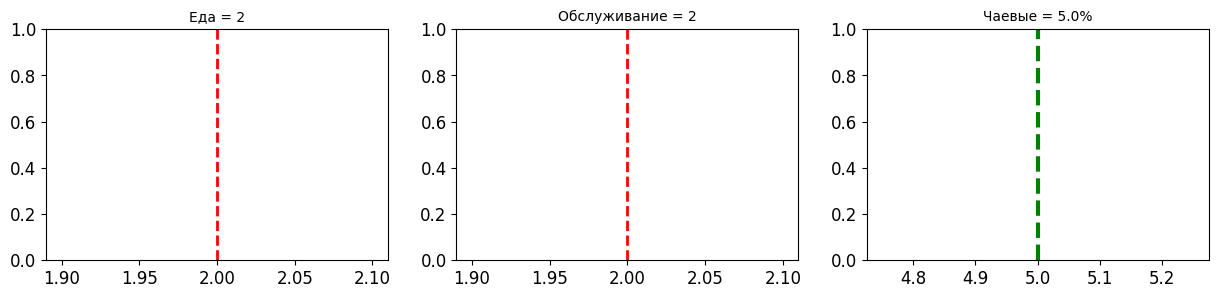

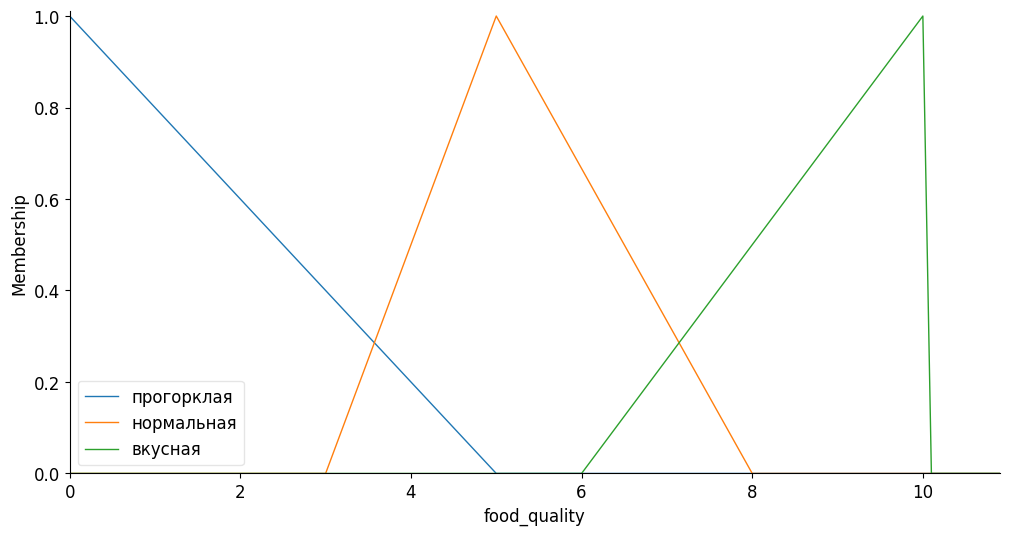

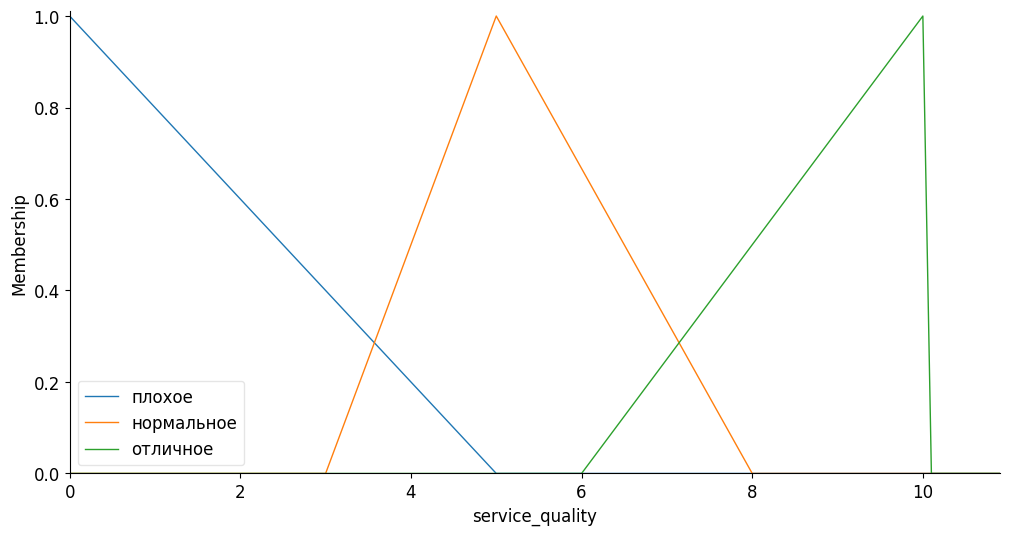

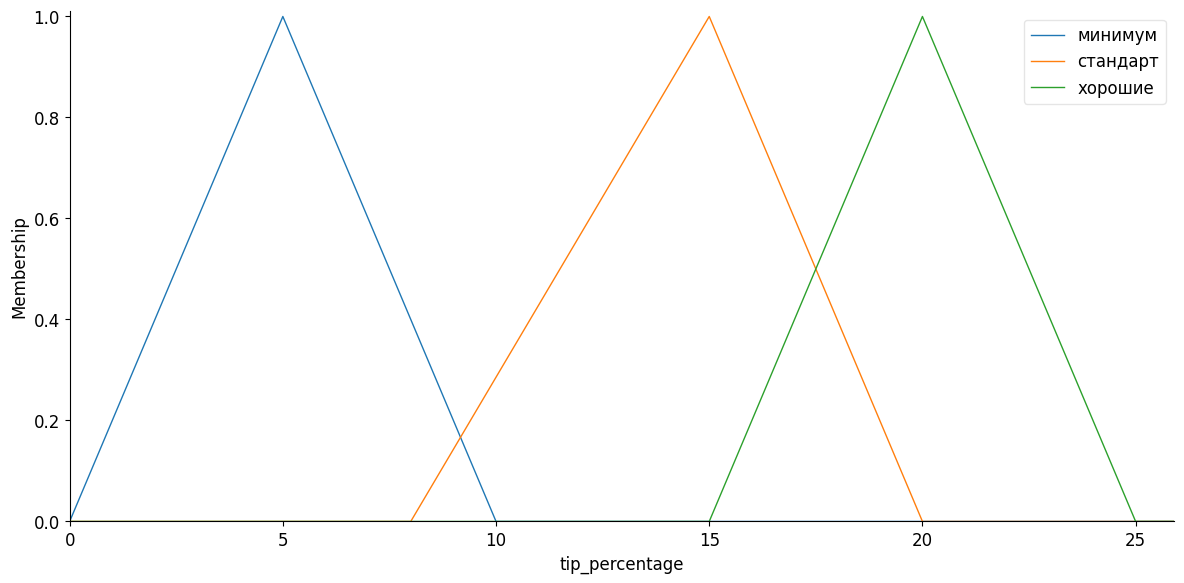


📌 Отличный сценарий:
   Еда = 9, Обслуживание = 9
   → Чаевые: 20.0%


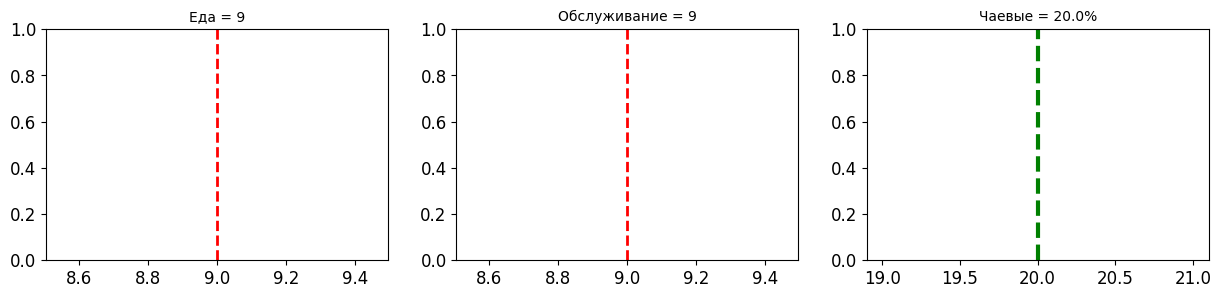

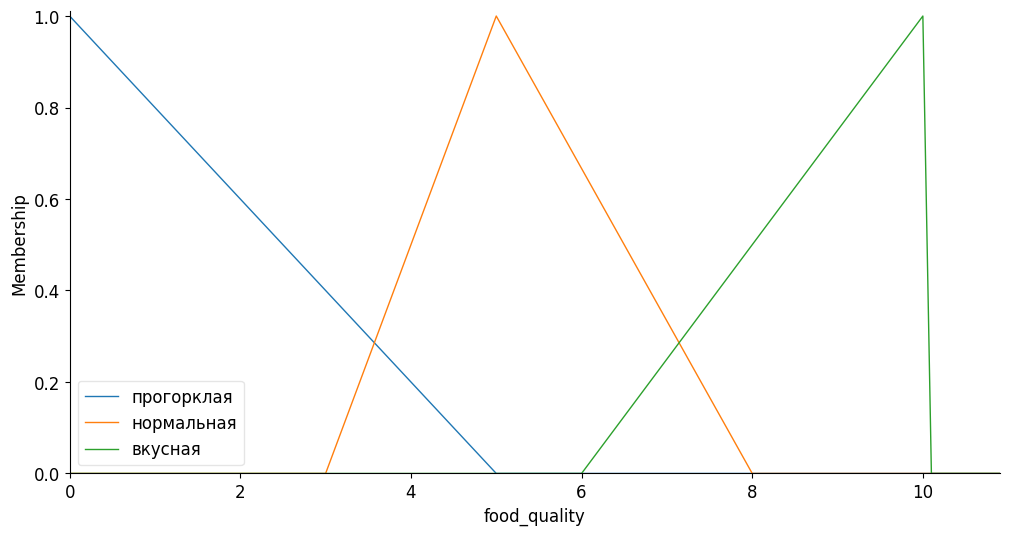

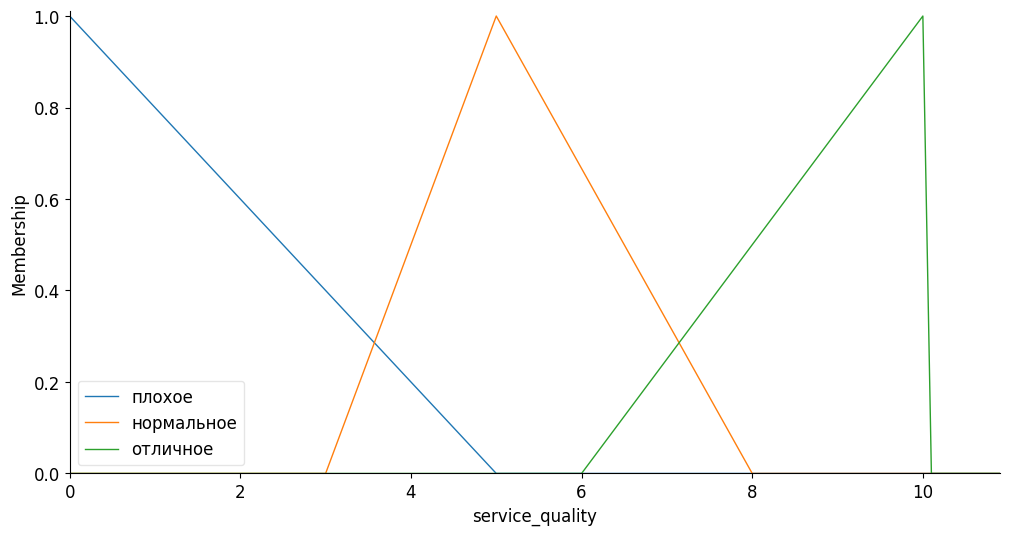

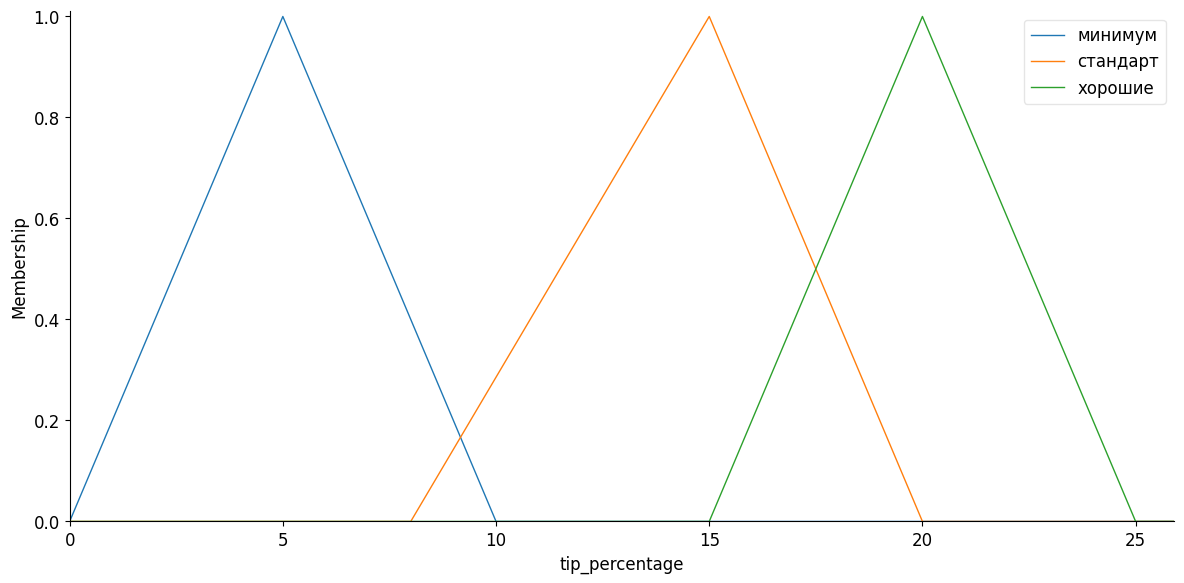


📌 Компромиссный вариант:
   Еда = 7, Обслуживание = 8
   → Чаевые: 16.3%


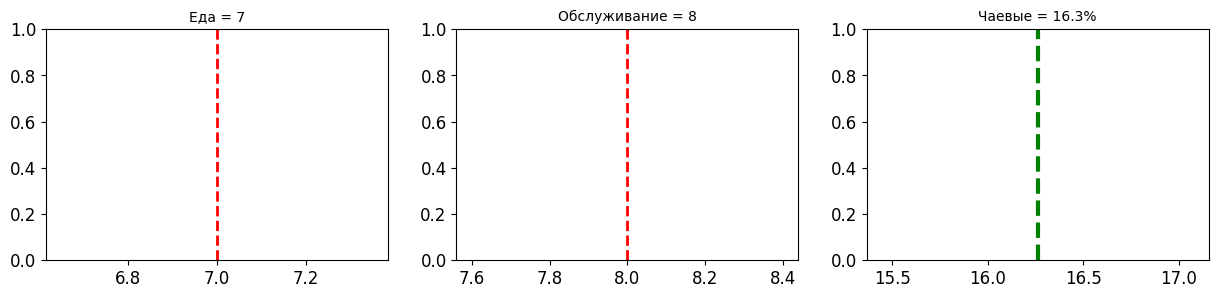

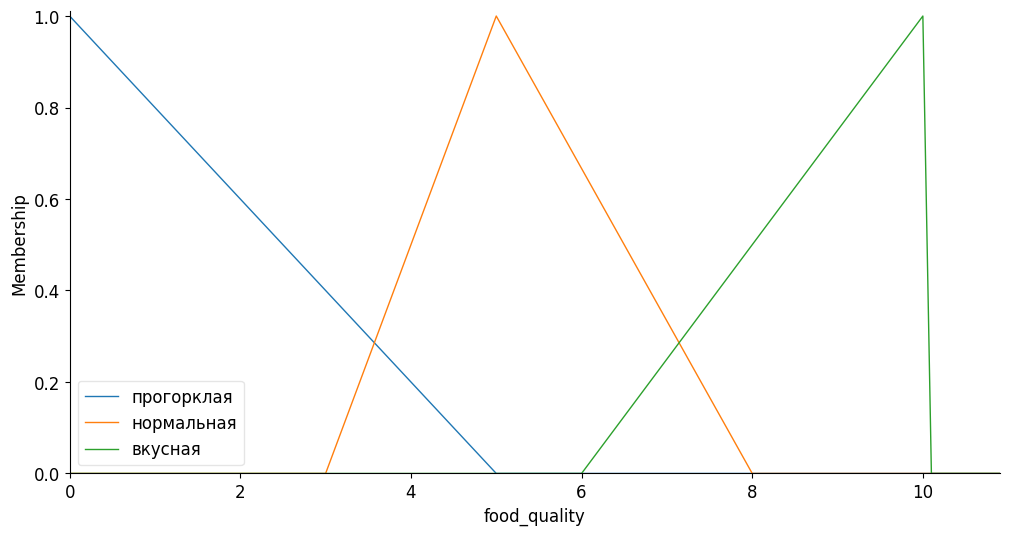

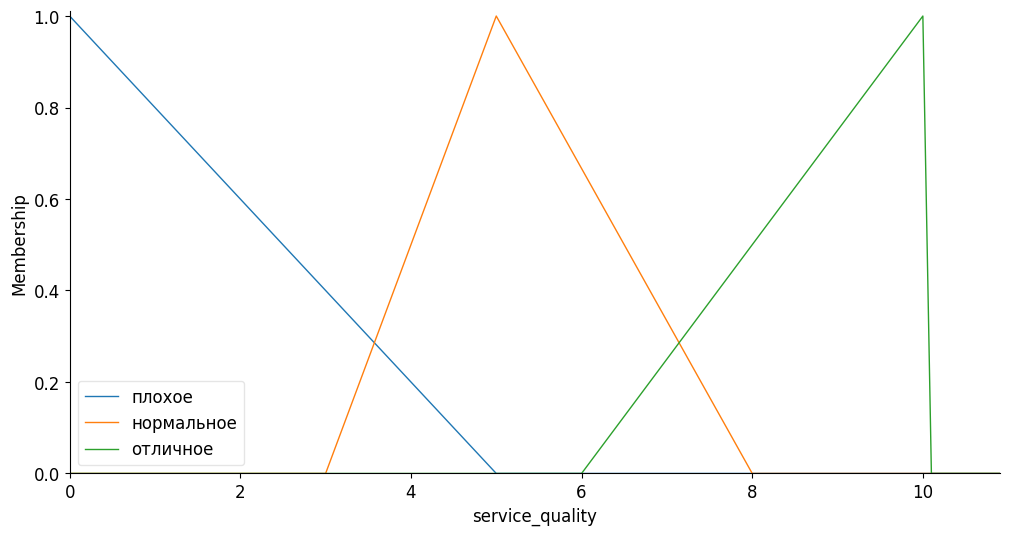

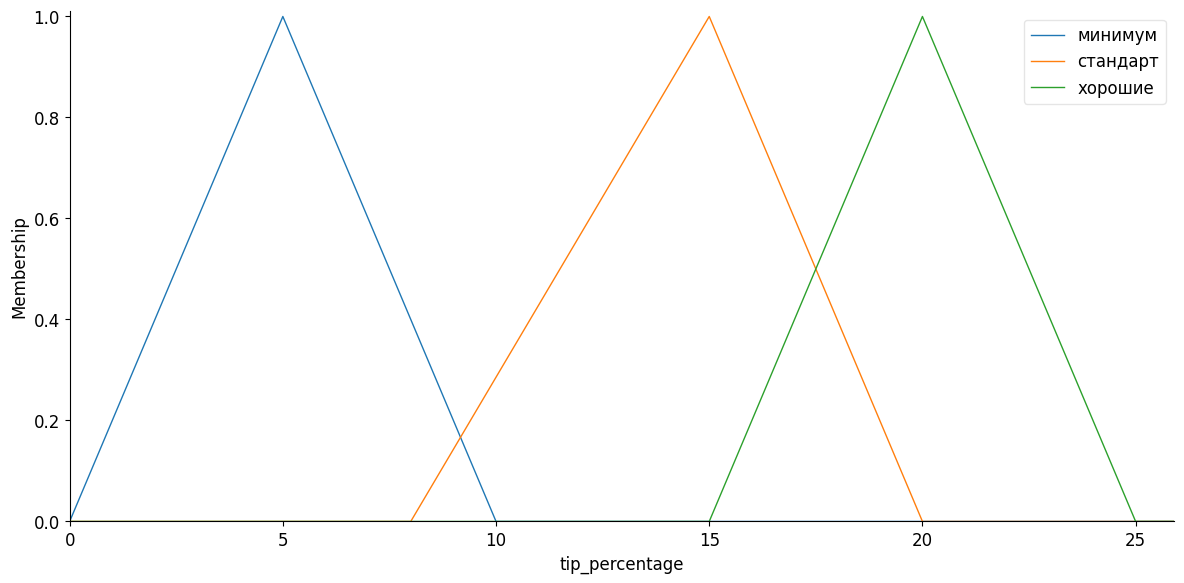


📌 Еда плохая, сервис отличный:
   Еда = 3, Обслуживание = 9
   → Чаевые: 5.0%


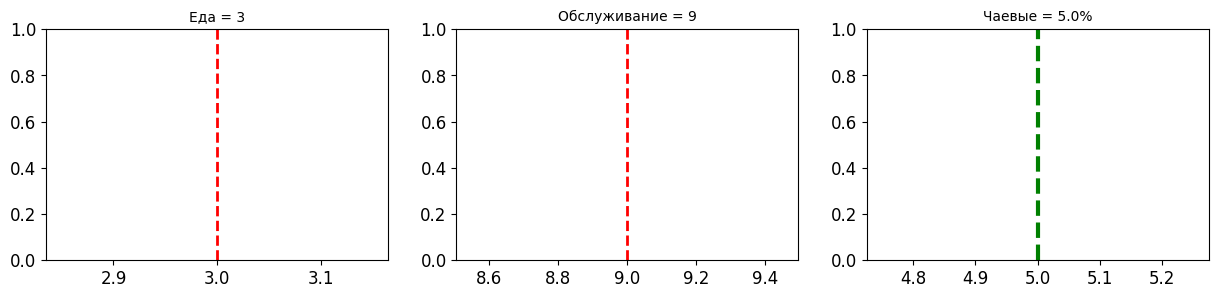

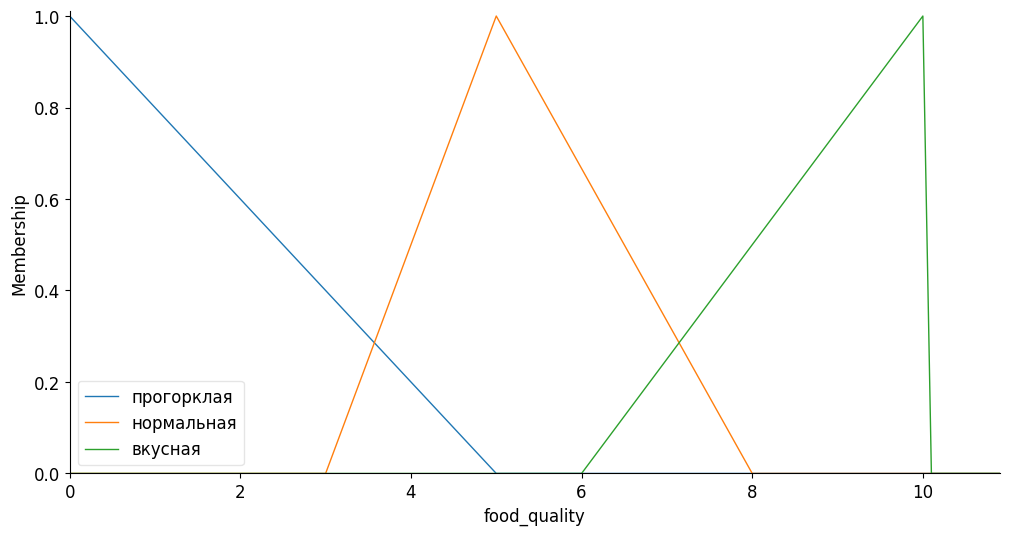

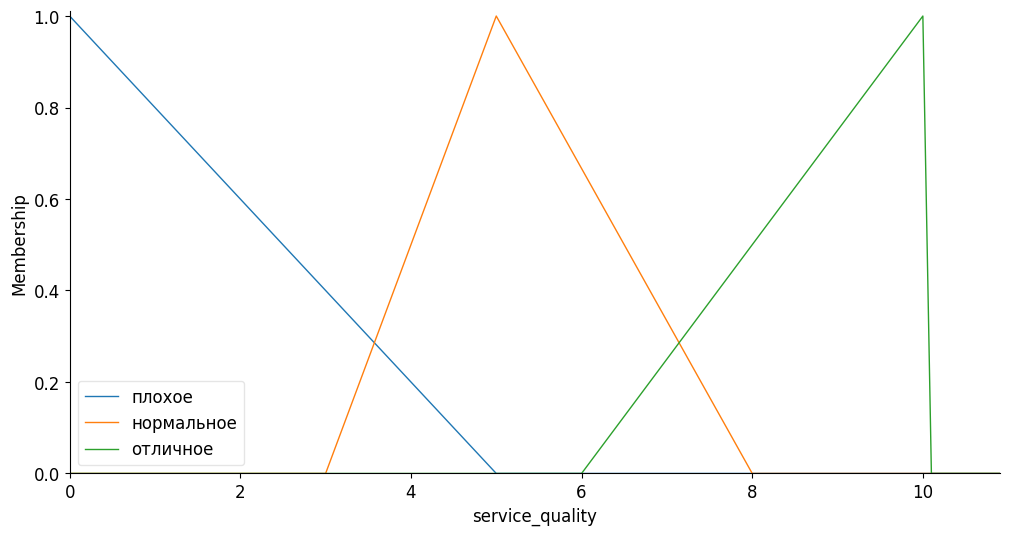

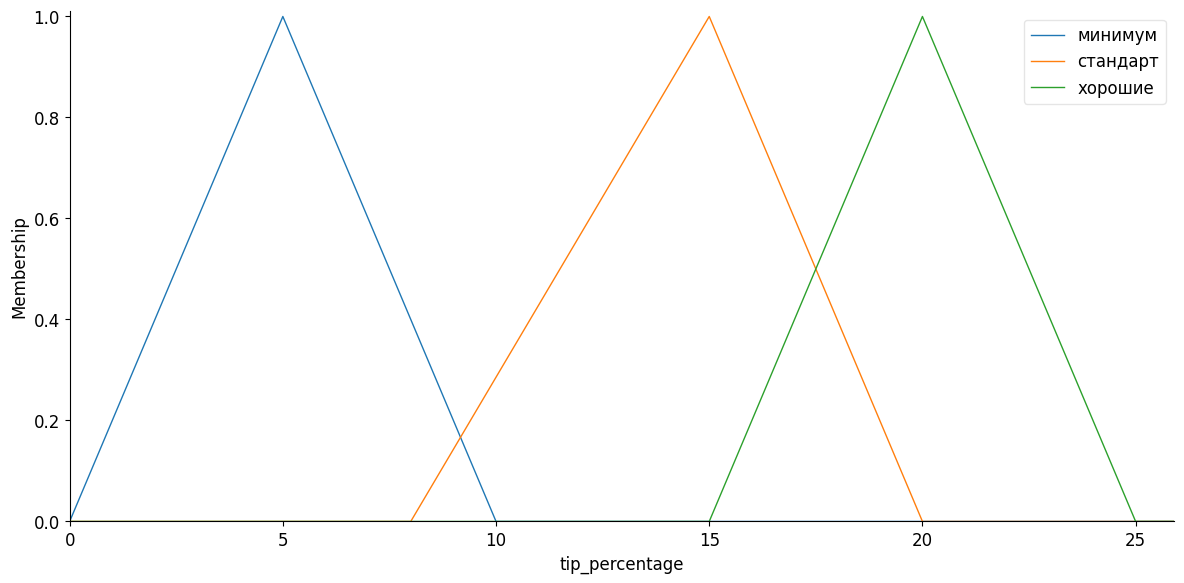


📌 Еда отличная, сервис плохой:
   Еда = 9, Обслуживание = 3
   → Чаевые: 5.0%


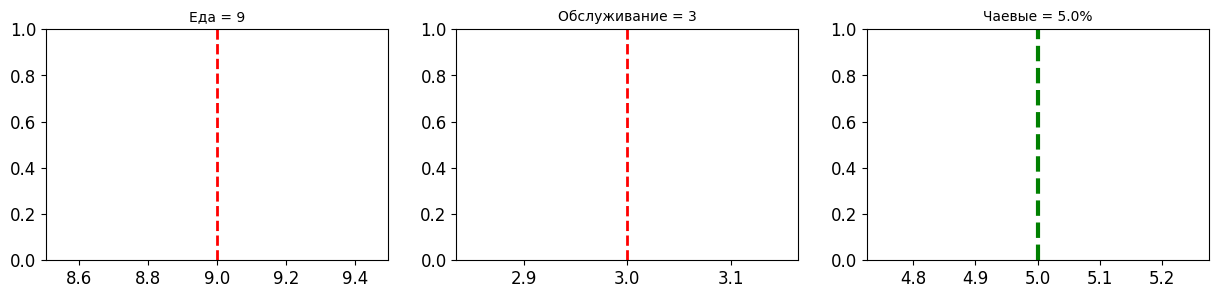

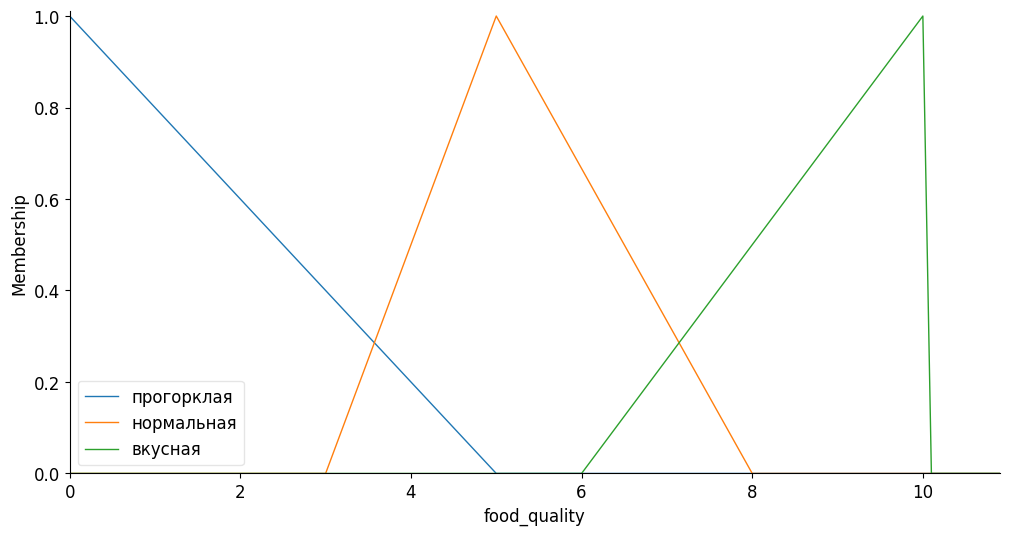

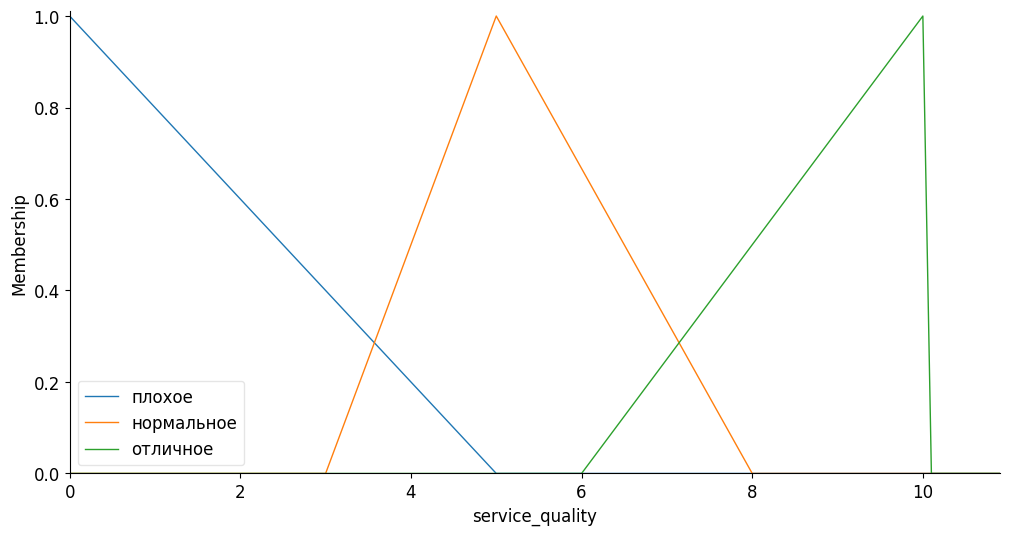

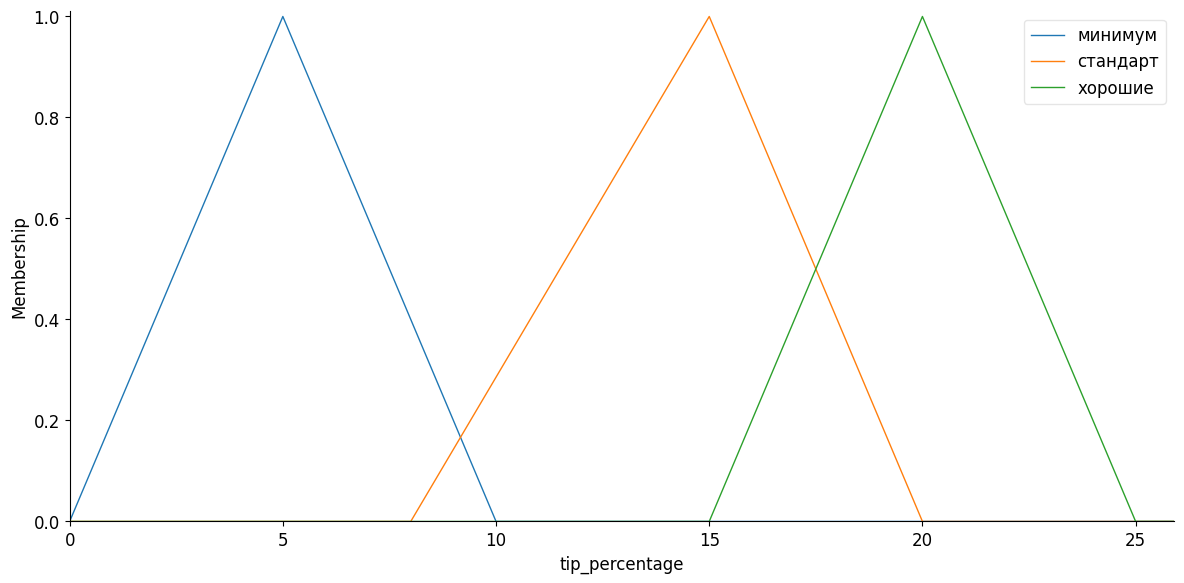


✅ Демонстрация завершена!
   Система успешно определяет чаевые в зависимости
   от качества еды и обслуживания


In [27]:
# ЯЧЕЙКА 22: Автоматический демонстрационный режим

print("=" * 60)
print("ДЕМОНСТРАЦИЯ РАБОТЫ КАЛЬКУЛЯТОРА")
print("=" * 60)

# Список тестовых случаев
test_cases = [
    (2, 2, "Плохой сценарий"),
    (9, 9, "Отличный сценарий"),
    (7, 8, "Компромиссный вариант"),
    (3, 9, "Еда плохая, сервис отличный"),
    (9, 3, "Еда отличная, сервис плохой")
]

for food_val, service_val, description in test_cases:
    print(f"\n📌 {description}:")
    print(f"   Еда = {food_val}, Обслуживание = {service_val}")
    
    tipping_sim.input['food_quality'] = food_val
    tipping_sim.input['service_quality'] = service_val
    tipping_sim.compute()
    tip_result = tipping_sim.output['tip_percentage']
    
    print(f"   → Чаевые: {tip_result:.1f}%")
    
    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    
    food.view(ax=axes[0])
    axes[0].axvline(x=food_val, color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'Еда = {food_val}', fontsize=10)
    
    service.view(ax=axes[1])
    axes[1].axvline(x=service_val, color='red', linestyle='--', linewidth=2)
    axes[1].set_title(f'Обслуживание = {service_val}', fontsize=10)
    
    tip.view(ax=axes[2])
    axes[2].axvline(x=tip_result, color='green', linestyle='--', linewidth=3)
    axes[2].set_title(f'Чаевые = {tip_result:.1f}%', fontsize=10)
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("✅ Демонстрация завершена!")
print("   Система успешно определяет чаевые в зависимости")
print("   от качества еды и обслуживания")
print("=" * 60)